# EchoMotion Code Demo

In [1]:
from matplotlib import colors
from numpy.core.function_base import linspace
import pandas as pd
import time
import tensorflow as tf
import keras
from mpl_toolkits import mplot3d
from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
import matplotlib.pyplot as plt
from IPython import display
import pylab as pl
from IPython import display
import math
import numpy as np
import pandas as pd
from scipy.io import wavfile

File_path = 'data/id_006/2023_11_22_15_00_37_216030_id_006_high_knee'
File_path_karas = File_path + '.karas'
file_name_full_path_without_extension = File_path
skeleton_name_full_path = File_path
sf, recording = wavfile.read(skeleton_name_full_path+".wav")


In [2]:
import os
import pandas as pd
import numpy as np
from scipy.io import wavfile
from tqdm import tqdm
from keras.layers import Conv2D, MaxPooling2D
from keras.layers import Dense, Dropout, Activation, Flatten
from keras import datasets, layers, models

from sklearn.model_selection import train_test_split
import tensorflow as tf
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn import svm, metrics
from matplotlib import pyplot as plt

 #  1 _ Create the To Model file

In [3]:
import os
import pandas as pd
import numpy as np
from scipy.io import wavfile
from tqdm import tqdm

# Define a function to process a single row and perform FFT on CPU using NumPy
def process_row(kinect_row):
    train_audio_fft = []
    for channel in range(0, number_of_channels):
        ch_ndarray = recording.T[channel]
        start_index = kinect_row * audio_samples_per_kinect_frame
        end_index = (kinect_row + 1) * audio_samples_per_kinect_frame
        study_audio_chunk = ch_ndarray[start_index:end_index]
        fft_of_chunk = np.fft.fft(study_audio_chunk)  # Calculate FFT using NumPy
        fft_focus = np.abs(fft_of_chunk[fft_range_from:fft_range_to])
        train_audio_fft.extend(fft_focus)
    return train_audio_fft

if __name__ == "__main__":
    # Set your file path here
    file_name_full_path_without_extension = File_path

    sf, recording = wavfile.read(file_name_full_path_without_extension + ".wav")
  
    ch1_ndarray = recording.T[0]
    ch2_ndarray = recording.T[1]
    ch3_ndarray = recording.T[2]
    ch4_ndarray = recording.T[3]
    ch5_ndarray = recording.T[4]
    ch6_ndarray = recording.T[5]
    ch7_ndarray = recording.T[6]

    print(len(ch1_ndarray), len(ch2_ndarray), len(ch3_ndarray), len(ch4_ndarray), len(ch5_ndarray), len(ch6_ndarray), len(ch7_ndarray))

    kinect_excel_df = pd.read_csv(file_name_full_path_without_extension + ".csv")
    print("audio samples count:", len(ch1_ndarray))
    print("sampling freq : ", sf)
    record_period = len(ch1_ndarray) / sf
    print("Recond period:", len(ch1_ndarray) / sf, " seconds")

    print("kinect excel frames count:", len(kinect_excel_df))
    print("columns count:", len(kinect_excel_df.columns))
    print("data columns:", len(kinect_excel_df.columns) - 2)
    print("Seconds / kinect frame : ", len(ch1_ndarray) / sf / len(kinect_excel_df))
    print("kinect f/s : ", len(kinect_excel_df) / record_period)

    audio_samples_per_kinect_frame = int(len(ch1_ndarray) / len(kinect_excel_df))
    print("audio samples / kinect frame : ", audio_samples_per_kinect_frame)

    number_of_channels = 7
    fft_range_from = 385
    fft_range_to = 495

    audio_titles = []
    for channel in range(0, number_of_channels):
        for x in range(fft_range_from, fft_range_to):
            audio_titles.extend(["channel" + str(channel) + "_" + str(x)])

    train_X_audio_df = pd.DataFrame(columns=audio_titles)

    frequencies = [17000, 17500, 18000, 18500, 19000, 19500, 20000, 20500, 21000]

    # Create a tqdm progress bar for the loop
    results = []
    for kinect_row in tqdm(range(len(kinect_excel_df)), desc="Processing"):
        train_audio_fft = process_row(kinect_row)
        results.append(train_audio_fft)

    train_X_audio_df = pd.DataFrame(results, columns=audio_titles)

    train_Y_Kinect_df = kinect_excel_df[[
        "pelvis_px", "pelvis_py", "pelvis_pz",
        "left shoulder_px", "left shoulder_py", "left shoulder_pz",
        "left elbow_px", "left elbow_py", "left elbow_pz",
        "left wrist_px", "left wrist_py", "left wrist_pz",
        "right shoulder_px", "right shoulder_py", "right shoulder_pz",
        "right elbow_px", "right elbow_py", "right elbow_pz",
        "right wrist_px", "right wrist_py", "right wrist_pz",
        "left hip_px", "left hip_py", "left hip_pz",
        "left knee_px", "left knee_py", "left knee_pz",
        "left ankle_px", "left ankle_py", "left ankle_pz",
        "right hip_px", "right hip_py", "right hip_pz",
        "right knee_px", "right knee_py", "right knee_pz",
        "right ankle_px", "right ankle_py", "right ankle_pz"]]


    all_dataframe = pd.concat([train_X_audio_df, train_Y_Kinect_df], axis=1, join='inner')

    all_dataframe.to_csv(file_name_full_path_without_extension + '_tomodel.csv', index=False)


6260736 6260736 6260736 6260736 6260736 6260736 6260736
audio samples count: 6260736
sampling freq :  44100
Recond period: 141.96680272108844  seconds
kinect excel frames count: 6114
columns count: 227
data columns: 225
Seconds / kinect frame :  0.023219954648526078
kinect f/s :  43.06640625
audio samples / kinect frame :  1024


Processing: 100%|█████████████████████████| 6114/6114 [00:00<00:00, 7922.76it/s]


# 2_ Run the main model 

Training data shape :  (4891, 770) (4891, 39)
Testing data shape :  (1223, 770) (1223, 39)
training 
Epoch 1/200
153/153 [==============================] - 2s 8ms/step - loss: 15833.6523 - mean_squared_error: 15833.6523 - val_loss: 6638.0210 - val_mean_squared_error: 6638.0210
Epoch 2/200
153/153 [==============================] - 1s 7ms/step - loss: 6075.8740 - mean_squared_error: 6075.8740 - val_loss: 5677.9663 - val_mean_squared_error: 5677.9663
Epoch 3/200
153/153 [==============================] - 1s 8ms/step - loss: 5720.6699 - mean_squared_error: 5720.6699 - val_loss: 5279.7847 - val_mean_squared_error: 5279.7847
Epoch 4/200
153/153 [==============================] - 1s 8ms/step - loss: 5205.9702 - mean_squared_error: 5205.9702 - val_loss: 4929.0972 - val_mean_squared_error: 4929.0972
Epoch 5/200
153/153 [==============================] - 1s 8ms/step - loss: 4727.9434 - mean_squared_error: 4727.9434 - val_loss: 4727.8818 - val_mean_squared_error: 4727.8818
Epoch 6/200
153/153 [=

153/153 [==============================] - 1s 8ms/step - loss: 396.8557 - mean_squared_error: 396.8557 - val_loss: 2241.2344 - val_mean_squared_error: 2241.2344
Epoch 95/200
153/153 [==============================] - 2s 10ms/step - loss: 236.9904 - mean_squared_error: 236.9904 - val_loss: 2101.2146 - val_mean_squared_error: 2101.2146
Epoch 96/200
153/153 [==============================] - 2s 14ms/step - loss: 297.3406 - mean_squared_error: 297.3406 - val_loss: 2224.7100 - val_mean_squared_error: 2224.7100
Epoch 97/200
153/153 [==============================] - 2s 15ms/step - loss: 287.7002 - mean_squared_error: 287.7002 - val_loss: 2171.2119 - val_mean_squared_error: 2171.2119
Epoch 98/200
153/153 [==============================] - 2s 11ms/step - loss: 218.7857 - mean_squared_error: 218.7857 - val_loss: 2274.6042 - val_mean_squared_error: 2274.6042
Epoch 99/200
153/153 [==============================] - 1s 9ms/step - loss: 267.9976 - mean_squared_error: 267.9976 - val_loss: 2267.3906 -

Epoch 141/200
153/153 [==============================] - 1s 9ms/step - loss: 214.0792 - mean_squared_error: 214.0792 - val_loss: 2113.9961 - val_mean_squared_error: 2113.9961
Epoch 142/200
153/153 [==============================] - 1s 10ms/step - loss: 190.5698 - mean_squared_error: 190.5698 - val_loss: 2357.3213 - val_mean_squared_error: 2357.3213
Epoch 143/200
153/153 [==============================] - 1s 9ms/step - loss: 174.1674 - mean_squared_error: 174.1674 - val_loss: 1982.7955 - val_mean_squared_error: 1982.7955
Epoch 144/200
153/153 [==============================] - 1s 10ms/step - loss: 170.4707 - mean_squared_error: 170.4707 - val_loss: 2024.4558 - val_mean_squared_error: 2024.4558
Epoch 145/200
153/153 [==============================] - 1s 9ms/step - loss: 192.9678 - mean_squared_error: 192.9678 - val_loss: 2047.1737 - val_mean_squared_error: 2047.1737
Epoch 146/200
153/153 [==============================] - 1s 9ms/step - loss: 192.1535 - mean_squared_error: 192.1535 - val_

Epoch 188/200
153/153 [==============================] - 1s 9ms/step - loss: 173.1463 - mean_squared_error: 173.1463 - val_loss: 2155.4453 - val_mean_squared_error: 2155.4453
Epoch 189/200
153/153 [==============================] - 2s 10ms/step - loss: 134.3780 - mean_squared_error: 134.3780 - val_loss: 1961.5864 - val_mean_squared_error: 1961.5864
Epoch 190/200
153/153 [==============================] - 1s 8ms/step - loss: 94.7533 - mean_squared_error: 94.7533 - val_loss: 1934.5803 - val_mean_squared_error: 1934.5803
Epoch 191/200
153/153 [==============================] - 1s 8ms/step - loss: 115.7826 - mean_squared_error: 115.7826 - val_loss: 2059.4763 - val_mean_squared_error: 2059.4763
Epoch 192/200
153/153 [==============================] - 1s 8ms/step - loss: 166.4401 - mean_squared_error: 166.4401 - val_loss: 1974.5178 - val_mean_squared_error: 1974.5178
Epoch 193/200
153/153 [==============================] - 2s 10ms/step - loss: 110.9361 - mean_squared_error: 110.9361 - val_lo

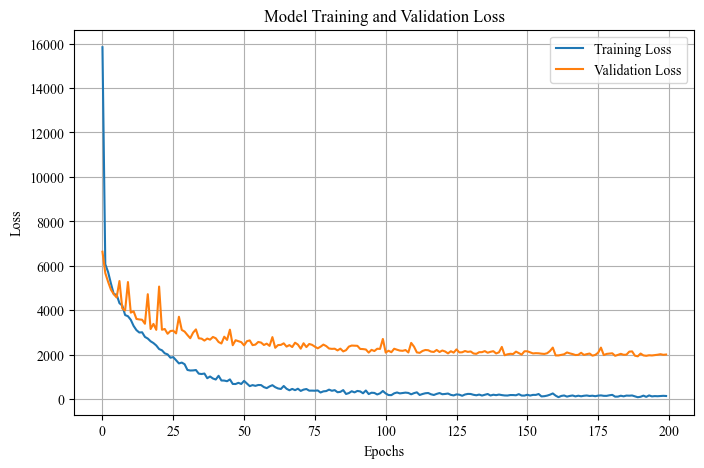

MAE: 25.905630436349636, MSE: 2013.6424483219923, RMSE: 44.87362753691741, MAPE: 0.216971773815144, R²: 0.6233138541081501
Error plot saved to /Users/mohammedmosuily/Library/CloudStorage/OneDrive-UniversityofSouthampton/#Southampton_PhD/data/id_006/2023_11_22_15_00_37_216030_id_006_high_knee_error_plot.png


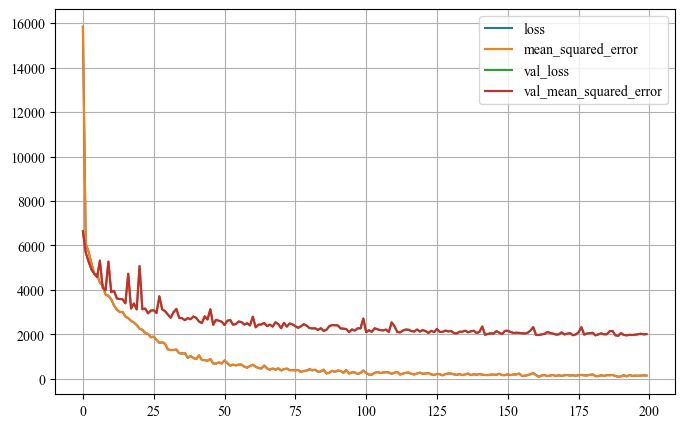

39/39 [==============================] - 0s 4ms/step
Mean Absolute Error: 25.91 %.


In [4]:
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error
import matplotlib.pyplot as plt
import matplotlib
import math


#X_Ys_df = pd.read_csv(file_name_full_path_without_extension+"_modified.csv")
X_Ys_df = pd.read_csv(file_name_full_path_without_extension+"_tomodel.csv")


columns_name = X_Ys_df.columns

X_columns_name = [] # 440 columns
for column_name in columns_name:
    if column_name[0:7] == "channel":
        X_columns_name.extend([column_name])

# pelvis_px

X_df = X_Ys_df[X_columns_name]

# print(X_df.columns)

X_np = np.array(X_df)

Y_columns_names = [
        "pelvis_px", "pelvis_py", "pelvis_pz",
        "left shoulder_px", "left shoulder_py", "left shoulder_pz",
        "left elbow_px", "left elbow_py", "left elbow_pz",
        "left wrist_px", "left wrist_py", "left wrist_pz",
        "right shoulder_px", "right shoulder_py", "right shoulder_pz",
        "right elbow_px", "right elbow_py", "right elbow_pz",
        "right wrist_px", "right wrist_py", "right wrist_pz",
        "left hip_px", "left hip_py", "left hip_pz",
        "left knee_px", "left knee_py", "left knee_pz",
        "left ankle_px", "left ankle_py", "left ankle_pz",
        "right hip_px", "right hip_py", "right hip_pz",
        "right knee_px", "right knee_py", "right knee_pz",
        "right ankle_px", "right ankle_py", "right ankle_pz"]
Y_np = np.array(X_Ys_df[Y_columns_names]) # 33

train_X , test_X , train_Y , test_Y = train_test_split(X_np, Y_np, test_size = 0.2)
print('Training data shape : ', train_X.shape, train_Y.shape)
print('Testing data shape : ', test_X.shape, test_Y.shape)


model = tf.keras.models.Sequential()

model.add(tf.keras.layers.Dense(units=650, activation=tf.nn.leaky_relu))
model.add(tf.keras.layers.Dense(units=500, activation=tf.nn.leaky_relu))
model.add(tf.keras.layers.Dense(units=450, activation=tf.nn.leaky_relu))
model.add(tf.keras.layers.Dense(units=300, activation=tf.nn.leaky_relu))
# model.add(tf.keras.layers.Dense(units=100,activation = tf.nn.leaky_relu))
# model.add(tf.keras.layers.Dense(units=100,activation = tf.nn.leaky_relu))
# model.add(tf.keras.layers.Dense(units=25,activation = tf.nn.leaky_relu))
model.add(tf.keras.layers.Dense(units=len(Y_columns_names) * 4,activation = tf.nn.leaky_relu)) # 132
model.add(tf.keras.layers.Dense(units=len(Y_columns_names),activation = tf.nn.leaky_relu)) # 39
model.compile(optimizer=tf.keras.optimizers.legacy.Adamax(), 
              loss=tf.keras.losses.MeanSquaredError(), 
              metrics=[tf.keras.metrics.MeanSquaredError()])




print("training ")
history = model.fit(train_X, train_Y, epochs=200, verbose=1, validation_data=(test_X, test_Y))
model.save(file_name_full_path_without_extension+".keras")

# Predictions and Metrics
predictions = model.predict(test_X)
mae = mean_absolute_error(test_Y, predictions)
mse = mean_squared_error(test_Y, predictions)
rmse = math.sqrt(mse)
mape = mean_absolute_percentage_error(test_Y, predictions)
r2 = r2_score(test_Y, predictions)

# Saving the metrics to a DataFrame and then to a CSV
metrics_df = pd.DataFrame([[mae, mse, rmse, mape, r2]],
                          columns=['MAE', 'MSE', 'RMSE', 'MAPE', 'R2'])
metrics_file = file_name_full_path_without_extension +'_metrics.csv'
metrics_df.to_csv(metrics_file, index=False)
print(f'Metrics saved to {metrics_file}')


# Plotting Training and Validation Loss
plt.figure(figsize=(8, 5))
matplotlib.rcParams['font.family'] = 'Times New Roman'
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Model Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Save the plot to a file
loss_plot_file = file_name_full_path_without_extension + '_loss_plot.png'
plt.savefig(loss_plot_file)
print(f'Loss plot saved to {loss_plot_file}')

# Show the plot
plt.show()

# Print metrics
print(f"MAE: {mae}, MSE: {mse}, RMSE: {rmse}, MAPE: {mape}, R²: {r2}")

# Plotting Error
pd.DataFrame(history.history).plot(figsize=(8,5))
plt.grid(True)

# Save the plot to a file
error_plot_file = file_name_full_path_without_extension + '_error_plot.png'
plt.savefig(error_plot_file)
print(f'Error plot saved to {error_plot_file}')

# Show the plot
plt.show()

# Mean Absolute Error calculation and printing
predictions_array = model.predict(test_X)
errors = abs(predictions_array - test_Y)
print('Mean Absolute Error:', round(np.mean(errors), 2), '%.')




In [5]:
import functions
functions.train_model_kfold(file_name_full_path_without_extension,5)

Training for fold 1 ...
Epoch 1/200
153/153 [==============================] - 1s 8ms/step - loss: 18246.9219 - mean_squared_error: 18246.9219 - val_loss: 6997.5767 - val_mean_squared_error: 6997.5767
Epoch 2/200
153/153 [==============================] - 1s 8ms/step - loss: 6643.3193 - mean_squared_error: 6643.3193 - val_loss: 6318.4185 - val_mean_squared_error: 6318.4185
Epoch 3/200
153/153 [==============================] - 1s 8ms/step - loss: 5685.0254 - mean_squared_error: 5685.0254 - val_loss: 5468.7173 - val_mean_squared_error: 5468.7173
Epoch 4/200
153/153 [==============================] - 2s 11ms/step - loss: 5410.7070 - mean_squared_error: 5410.7070 - val_loss: 5170.2285 - val_mean_squared_error: 5170.2285
Epoch 5/200
153/153 [==============================] - 2s 13ms/step - loss: 4972.3862 - mean_squared_error: 4972.3862 - val_loss: 4906.2612 - val_mean_squared_error: 4906.2612
Epoch 6/200
153/153 [==============================] - 2s 11ms/step - loss: 4579.8052 - mean_squa

153/153 [==============================] - 1s 9ms/step - loss: 254.3057 - mean_squared_error: 254.3057 - val_loss: 2262.6094 - val_mean_squared_error: 2262.6094
Epoch 95/200
153/153 [==============================] - 1s 9ms/step - loss: 361.4243 - mean_squared_error: 361.4243 - val_loss: 2444.8911 - val_mean_squared_error: 2444.8911
Epoch 96/200
153/153 [==============================] - 1s 9ms/step - loss: 284.0427 - mean_squared_error: 284.0427 - val_loss: 2125.0134 - val_mean_squared_error: 2125.0134
Epoch 97/200
153/153 [==============================] - 1s 9ms/step - loss: 323.9654 - mean_squared_error: 323.9654 - val_loss: 2209.4202 - val_mean_squared_error: 2209.4202
Epoch 98/200
153/153 [==============================] - 1s 8ms/step - loss: 264.4534 - mean_squared_error: 264.4534 - val_loss: 2131.0664 - val_mean_squared_error: 2131.0664
Epoch 99/200
153/153 [==============================] - 1s 9ms/step - loss: 232.1811 - mean_squared_error: 232.1811 - val_loss: 2286.6687 - val

Epoch 141/200
153/153 [==============================] - 1s 9ms/step - loss: 168.7994 - mean_squared_error: 168.7994 - val_loss: 2027.9086 - val_mean_squared_error: 2027.9086
Epoch 142/200
153/153 [==============================] - 1s 8ms/step - loss: 149.7691 - mean_squared_error: 149.7691 - val_loss: 2084.7280 - val_mean_squared_error: 2084.7280
Epoch 143/200
153/153 [==============================] - 1s 8ms/step - loss: 200.4691 - mean_squared_error: 200.4691 - val_loss: 2031.2452 - val_mean_squared_error: 2031.2452
Epoch 144/200
153/153 [==============================] - 1s 9ms/step - loss: 157.5331 - mean_squared_error: 157.5331 - val_loss: 2099.4998 - val_mean_squared_error: 2099.4998
Epoch 145/200
153/153 [==============================] - 1s 9ms/step - loss: 231.3524 - mean_squared_error: 231.3524 - val_loss: 2083.4331 - val_mean_squared_error: 2083.4331
Epoch 146/200
153/153 [==============================] - 1s 9ms/step - loss: 212.1028 - mean_squared_error: 212.1028 - val_lo

Epoch 188/200
153/153 [==============================] - 1s 9ms/step - loss: 126.5400 - mean_squared_error: 126.5400 - val_loss: 2044.3158 - val_mean_squared_error: 2044.3158
Epoch 189/200
153/153 [==============================] - 2s 13ms/step - loss: 153.4815 - mean_squared_error: 153.4815 - val_loss: 1984.3157 - val_mean_squared_error: 1984.3157
Epoch 190/200
153/153 [==============================] - 1s 9ms/step - loss: 148.2857 - mean_squared_error: 148.2857 - val_loss: 1983.5294 - val_mean_squared_error: 1983.5294
Epoch 191/200
153/153 [==============================] - 2s 10ms/step - loss: 178.2527 - mean_squared_error: 178.2527 - val_loss: 2027.9706 - val_mean_squared_error: 2027.9706
Epoch 192/200
153/153 [==============================] - 2s 10ms/step - loss: 119.1754 - mean_squared_error: 119.1754 - val_loss: 1909.6182 - val_mean_squared_error: 1909.6182
Epoch 193/200
153/153 [==============================] - 2s 10ms/step - loss: 112.7558 - mean_squared_error: 112.7558 - va

Epoch 34/200
153/153 [==============================] - 1s 8ms/step - loss: 1227.7604 - mean_squared_error: 1227.7604 - val_loss: 2752.9873 - val_mean_squared_error: 2752.9873
Epoch 35/200
153/153 [==============================] - 1s 9ms/step - loss: 1170.9506 - mean_squared_error: 1170.9506 - val_loss: 2623.2451 - val_mean_squared_error: 2623.2451
Epoch 36/200
153/153 [==============================] - 2s 11ms/step - loss: 1112.8252 - mean_squared_error: 1112.8252 - val_loss: 2638.3860 - val_mean_squared_error: 2638.3860
Epoch 37/200
153/153 [==============================] - 2s 11ms/step - loss: 1038.2191 - mean_squared_error: 1038.2191 - val_loss: 2794.4668 - val_mean_squared_error: 2794.4668
Epoch 38/200
153/153 [==============================] - 2s 10ms/step - loss: 1058.4801 - mean_squared_error: 1058.4801 - val_loss: 2884.1611 - val_mean_squared_error: 2884.1611
Epoch 39/200
153/153 [==============================] - 2s 10ms/step - loss: 968.7716 - mean_squared_error: 968.7716 

...

Epoch 196/200
153/153 [==============================] - 1s 9ms/step - loss: 129.9904 - mean_squared_error: 129.9904 - val_loss: 1974.9922 - val_mean_squared_error: 1974.9922
Epoch 197/200
153/153 [==============================] - 1s 8ms/step - loss: 173.2330 - mean_squared_error: 173.2330 - val_loss: 1894.3577 - val_mean_squared_error: 1894.3577
Epoch 198/200
153/153 [==============================] - 1s 8ms/step - loss: 117.3192 - mean_squared_error: 117.3192 - val_loss: 1893.1725 - val_mean_squared_error: 1893.1725
Epoch 199/200
153/153 [==============================] - 1s 9ms/step - loss: 134.8183 - mean_squared_error: 134.8183 - val_loss: 2010.4615 - val_mean_squared_error: 2010.4615
Epoch 200/200
39/39 [==============================] - 0s 5ms/step
Mean Absolute Error: 24.913953361463516 %.
Training for fold 5 ...
Epoch 1/200
153/153 [==============================] - 2s 9ms/step - loss: 15921.4375 - mean_squared_error: 15921.4375 - val_loss: 6731.9990 - val_mean_squared_error:

Epoch 42/200
153/153 [==============================] - 1s 8ms/step - loss: 815.0789 - mean_squared_error: 815.0789 - val_loss: 2687.2886 - val_mean_squared_error: 2687.2886
Epoch 43/200
153/153 [==============================] - 1s 8ms/step - loss: 903.7779 - mean_squared_error: 903.7779 - val_loss: 2963.4685 - val_mean_squared_error: 2963.4685
Epoch 44/200
153/153 [==============================] - 1s 8ms/step - loss: 761.1622 - mean_squared_error: 761.1622 - val_loss: 2749.0083 - val_mean_squared_error: 2749.0083
Epoch 45/200
153/153 [==============================] - 1s 8ms/step - loss: 797.8815 - mean_squared_error: 797.8815 - val_loss: 2651.5640 - val_mean_squared_error: 2651.5640
Epoch 46/200
153/153 [==============================] - 1s 7ms/step - loss: 682.0652 - mean_squared_error: 682.0652 - val_loss: 2567.9180 - val_mean_squared_error: 2567.9180
Epoch 47/200
153/153 [==============================] - 1s 8ms/step - loss: 666.3997 - mean_squared_error: 666.3997 - val_loss: 25

153/153 [==============================] - 1s 9ms/step - loss: 314.7887 - mean_squared_error: 314.7887 - val_loss: 2316.4778 - val_mean_squared_error: 2316.4778
Epoch 90/200
153/153 [==============================] - 1s 9ms/step - loss: 255.0378 - mean_squared_error: 255.0378 - val_loss: 2245.7581 - val_mean_squared_error: 2245.7581
Epoch 91/200
153/153 [==============================] - 1s 8ms/step - loss: 322.0737 - mean_squared_error: 322.0737 - val_loss: 2245.2505 - val_mean_squared_error: 2245.2505
Epoch 92/200
153/153 [==============================] - 1s 9ms/step - loss: 332.5144 - mean_squared_error: 332.5144 - val_loss: 2193.8511 - val_mean_squared_error: 2193.8511
Epoch 93/200
153/153 [==============================] - 1s 8ms/step - loss: 268.2580 - mean_squared_error: 268.2580 - val_loss: 2286.5791 - val_mean_squared_error: 2286.5791
Epoch 94/200
153/153 [==============================] - 1s 8ms/step - loss: 372.8951 - mean_squared_error: 372.8951 - val_loss: 2261.1455 - val

Epoch 136/200
153/153 [==============================] - 1s 8ms/step - loss: 185.1257 - mean_squared_error: 185.1257 - val_loss: 2142.7683 - val_mean_squared_error: 2142.7683
Epoch 137/200
153/153 [==============================] - 1s 7ms/step - loss: 242.6018 - mean_squared_error: 242.6018 - val_loss: 2114.4348 - val_mean_squared_error: 2114.4348
Epoch 138/200
153/153 [==============================] - 1s 7ms/step - loss: 184.9310 - mean_squared_error: 184.9310 - val_loss: 2269.8105 - val_mean_squared_error: 2269.8105
Epoch 139/200
153/153 [==============================] - 1s 8ms/step - loss: 183.7402 - mean_squared_error: 183.7402 - val_loss: 2181.1780 - val_mean_squared_error: 2181.1780
Epoch 140/200
153/153 [==============================] - 1s 7ms/step - loss: 168.2225 - mean_squared_error: 168.2225 - val_loss: 2141.5125 - val_mean_squared_error: 2141.5125
Epoch 141/200
153/153 [==============================] - 1s 7ms/step - loss: 213.6230 - mean_squared_error: 213.6230 - val_lo

Epoch 183/200
153/153 [==============================] - 1s 9ms/step - loss: 120.2398 - mean_squared_error: 120.2398 - val_loss: 2044.8713 - val_mean_squared_error: 2044.8713
Epoch 184/200
153/153 [==============================] - 1s 9ms/step - loss: 130.1676 - mean_squared_error: 130.1676 - val_loss: 2111.8284 - val_mean_squared_error: 2111.8284
Epoch 185/200
153/153 [==============================] - 1s 9ms/step - loss: 181.0516 - mean_squared_error: 181.0516 - val_loss: 2023.5554 - val_mean_squared_error: 2023.5554
Epoch 186/200
153/153 [==============================] - 1s 9ms/step - loss: 119.4601 - mean_squared_error: 119.4601 - val_loss: 2043.3224 - val_mean_squared_error: 2043.3224
Epoch 187/200
153/153 [==============================] - 1s 9ms/step - loss: 161.2403 - mean_squared_error: 161.2403 - val_loss: 2345.3806 - val_mean_squared_error: 2345.3806
Epoch 188/200
153/153 [==============================] - 1s 9ms/step - loss: 166.8190 - mean_squared_error: 166.8190 - val_lo

39/39 [==============================] - 0s 6ms/step
Root Mean Square Error: 44.87362753691742
PCKh@0.5: 0.8694257500471728


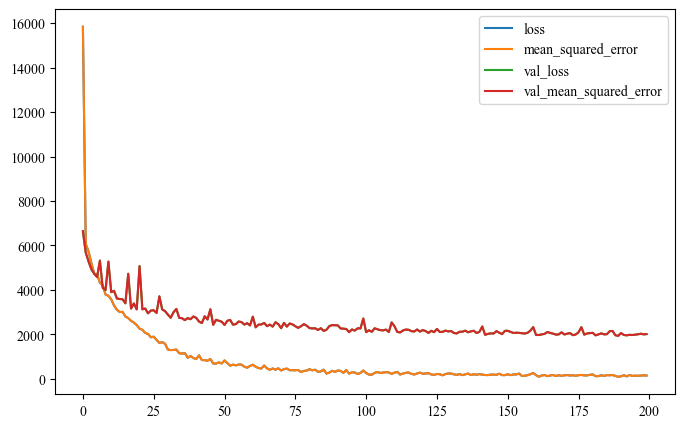

In [6]:


# After model prediction
predictions_array = model.predict(test_X)

# RMSE Calculation
mse = np.mean((predictions_array - test_Y) ** 2)
rmse = np.sqrt(mse)
print('Root Mean Square Error:', rmse)

def calculate_pckh(test_Y, predictions_array, head_segment_length):
    correct_keypoints = 0
    total_keypoints = 0

    for true, pred in zip(test_Y, predictions_array):
        for i in range(len(true)//3): # Assuming keypoints are in (x,y,z) format
            if np.linalg.norm(true[i*3:(i+1)*3] - pred[i*3:(i+1)*3]) < 0.5 * head_segment_length:
                correct_keypoints += 1
            total_keypoints += 1

    return correct_keypoints / total_keypoints

head_segment_length = 200  # Replace this with your actual head segment length calculation
pckh = calculate_pckh(test_Y, predictions_array, head_segment_length)
print('PCKh@0.5:', pckh)

# Plotting the training history
pd.DataFrame(history.history).plot(figsize=(8,5))
plt.show()


# 3_ Create the to angle file

In [7]:

def angle_triangle(x1, x2, x3, y1, y2, y3, z1, z2, z3):

    # angle at y
    xy = math.sqrt((x1-y1)**2+(x2-y2)**2+(x3-y3)**2)
    zy = math.sqrt((z1-y1)**2+(z2-y2)**2+(z3-y3)**2)
    xz = math.sqrt((x1-z1)**2+(x2-z2)**2+(x3-z3)**2)
    # print(xy,xz,zy)
    if xy != 0 and xz != 0:
      y = np.arccos((xy**2 + zy**2 - xz**2)/2/xy/zy) * 180 / math.pi
    else:
      y = 0

    # num = (x2-x1)*(x3-x1)+(y2-y1)*(y3-y1)+(z2-z1)*(z3-z1)
    # den = math.sqrt((x2-x1)**2+(y2-y1)**2+(z2-z1)**2)*\
    #             math.sqrt((x3-x1)**2+(y3-y1)**2+(z3-z1)**2)
    # if den == 0:
    #   print(num)
    #   angle = 0
    # else:
    #   angle = math.degrees(math.acos(num / den))

    return round(y, 3)


In [8]:
# 
# file_name_full_path_without_extension = 'trainsample6/2023_09_24_20_31_46_jumping_jacks'
def play_model(file_name_full_path_without_extension,number_of_channels):

    model_name_full_path_without_extension = file_name_full_path_without_extension + '.keras'

    model = keras.models.load_model(model_name_full_path_without_extension)
    df_kinect_depth = pd.read_csv(file_name_full_path_without_extension+".csv")
    df = pd.read_csv(file_name_full_path_without_extension+"_tomodel.csv")

    fft_range_from = 385
    fft_range_to = 495
    audio_titles = []
    for channel in range(0,number_of_channels):
        for x in range(fft_range_from,fft_range_to):
            audio_titles.extend(["channel"+str(channel)+"_"+str(x)])

    train_X_audio_np = np.array(df[audio_titles]) #

    # fig = plt.figure()
    # ax = plt.add_subplot(121,projection='3d')
    # fig2 = plt.figure(2)
    
    X_columns_names = ["pelvis_px"
    ,"left shoulder_px","left elbow_px","left wrist_px"
    ,"right shoulder_px","right elbow_px","right wrist_px"
    ,"left hip_px","left knee_px","left ankle_px"
    ,"right hip_px","right knee_px","right ankle_px"]
    Y_columns_names = ["pelvis_py"
    ,"left shoulder_py","left elbow_py","left wrist_py"
    ,"right shoulder_py","right elbow_py","right wrist_py"
    ,"left hip_py","left knee_py","left ankle_py"
    ,"right hip_py","right knee_py","right ankle_py"]
    Z_columns_names = ["pelvis_pz"
    ,"left shoulder_pz","left elbow_pz","left wrist_pz"
    ,"right shoulder_pz","right elbow_pz","right wrist_pz"
    ,"left hip_pz","left knee_pz","left ankle_pz"
    ,"right hip_pz","right knee_pz","right ankle_pz"]
    skeleton_Xs_np = np.array(df[X_columns_names]) #
    skeleton_Ys_np = np.array(df[Y_columns_names]) #
    skeleton_Zs_np = np.array(df[Z_columns_names]) #

    plt.ion()
    fig = plt.figure(figsize=(15, 15))
    ax = fig.add_subplot(211, projection='3d')
    ax2 = fig.add_subplot(212)
    sc = ax.scatter([np.amin(skeleton_Xs_np), np.amax(skeleton_Xs_np)],
                   [np.amin(skeleton_Ys_np), np.amax(skeleton_Ys_np)],
               [np.amin(skeleton_Zs_np), np.amax(skeleton_Zs_np)])
    
    # Set titles and labels
    ax.set_title('3D Skeleton Plot')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')

    ax2.set_title('Depth Image')
    ax2.set_xlabel('X')
    ax2.set_ylabel('Y')

    
    print(skeleton_Xs_np.shape)
    for index_ref,row_ref in df.iterrows():
        print("frame ", index_ref , " of " , len(df))

        
        ax.cla()
        ax2.cla()


        depth_image_str = df_kinect_depth.loc[index_ref,'depthimage'][1:-1]
        depth_image_1d_np = np.fromstring(depth_image_str, dtype=int, sep=' ')
        depth_image_2d_np = np.reshape(depth_image_1d_np,(128,128))
        ax2.imshow(depth_image_2d_np)
        # plt.imshow(depth_image_2d_np, interpolation='nearest')
        # plt.show()
        
        # ax2.sub(depth_image_2d_np)

        test_audio = [train_X_audio_np[index_ref].tolist()]
        # print("test_audio",test_audio[0])
        # print("test_audio1",type(test_audio))
        # print("test_audio2",len(test_audio[0]))
        predictions_array = model.predict(test_audio,verbose = 0)


        # print(predictions_array)
        # print(type(predictions_array))
        # print(len(predictions_array))

        xline = np.array([df.loc[index_ref,'right shoulder_px'],df.loc[index_ref,'left shoulder_px']])
        yline = np.array([df.loc[index_ref,'right shoulder_py'],df.loc[index_ref,'left shoulder_py']])
        zline = np.array([df.loc[index_ref,'right shoulder_pz'],df.loc[index_ref,'left shoulder_pz']])
        ## ax.plot3D(xline, yline, zline, 'green')
        ax.plot(xline, yline, zline,color='green')
        xline = np.array([predictions_array[0][12],predictions_array[0][3]])
        yline = np.array([predictions_array[0][13],predictions_array[0][4]])
        zline = np.array([predictions_array[0][14],predictions_array[0][5]])
        ax.plot(xline, yline, zline,color='red')
        df.loc[index_ref,['right shoulder_px predicted','right shoulder_py predicted','right shoulder_pz predicted']] = [predictions_array[0][12],predictions_array[0][13],predictions_array[0][14]]
        df.loc[index_ref,['left shoulder_px predicted','left shoulder_py predicted','left shoulder_pz predicted']] = predictions_array[0][3],predictions_array[0][4],predictions_array[0][4]


        xline = np.array([df.loc[index_ref,'left elbow_px'],df.loc[index_ref,'left shoulder_px']])
        yline = np.array([df.loc[index_ref,'left elbow_py'],df.loc[index_ref,'left shoulder_py']])
        zline = np.array([df.loc[index_ref,'left elbow_pz'],df.loc[index_ref,'left shoulder_pz']])
        # # ax.plot3D(xline, yline, zline, 'green')
        ax.plot(xline, yline, zline,color='green')
        xline = np.array([predictions_array[0][6],predictions_array[0][3]])
        yline = np.array([predictions_array[0][7],predictions_array[0][4]])
        zline = np.array([predictions_array[0][8],predictions_array[0][5]])
        ax.plot(xline, yline, zline,color='red')
        df.loc[index_ref,'left elbow_px predicted'] = predictions_array[0][6]
        df.loc[index_ref,'left elbow_py predicted'] = predictions_array[0][7]
        df.loc[index_ref,'left elbow_pz predicted'] = predictions_array[0][8]


        xline = np.array([df.loc[index_ref,'left elbow_px'],df.loc[index_ref,'left wrist_px']])
        yline = np.array([df.loc[index_ref,'left elbow_py'],df.loc[index_ref,'left wrist_py']])
        zline = np.array([df.loc[index_ref,'left elbow_pz'],df.loc[index_ref,'left wrist_pz']])
        # # ax.plot3D(xline, yline, zline, 'green')
        ax.plot(xline, yline, zline,color='green')
        xline = np.array([predictions_array[0][6],predictions_array[0][9]])
        yline = np.array([predictions_array[0][7],predictions_array[0][10]])
        zline = np.array([predictions_array[0][8],predictions_array[0][11]])
        ax.plot(xline, yline, zline,color='red')
        df.loc[index_ref,'left wrist_px predicted'] = predictions_array[0][9]
        df.loc[index_ref,'left wrist_py predicted'] = predictions_array[0][10]
        df.loc[index_ref,'left wrist_pz predicted'] = predictions_array[0][11]


        xline = np.array([df.loc[index_ref,'right elbow_px'],df.loc[index_ref,'right shoulder_px']])
        yline = np.array([df.loc[index_ref,'right elbow_py'],df.loc[index_ref,'right shoulder_py']])
        zline = np.array([df.loc[index_ref,'right elbow_pz'],df.loc[index_ref,'right shoulder_pz']])
        # # ax.plot3D(xline, yline, zline, 'green')
        ax.plot(xline, yline, zline,color='green')
        xline = np.array([predictions_array[0][15],predictions_array[0][12]])
        yline = np.array([predictions_array[0][16],predictions_array[0][13]])
        zline = np.array([predictions_array[0][17],predictions_array[0][14]])
        ax.plot(xline, yline, zline,color='red')
        df.loc[index_ref,'right elbow_px predicted'] = predictions_array[0][15]
        df.loc[index_ref,'right elbow_py predicted'] = predictions_array[0][16]
        df.loc[index_ref,'right elbow_pz predicted'] = predictions_array[0][17]


        xline = np.array([df.loc[index_ref,'right elbow_px'],df.loc[index_ref,'right wrist_px']])
        yline = np.array([df.loc[index_ref,'right elbow_py'],df.loc[index_ref,'right wrist_py']])
        zline = np.array([df.loc[index_ref,'right elbow_pz'],df.loc[index_ref,'right wrist_pz']])
        # # ax.plot3D(xline, yline, zline, 'green')
        ax.plot(xline, yline, zline,color='green')
        xline = np.array([predictions_array[0][15],predictions_array[0][18]])
        yline = np.array([predictions_array[0][16],predictions_array[0][19]])
        zline = np.array([predictions_array[0][17],predictions_array[0][20]])
        ax.plot(xline, yline, zline,color='red')
        df.loc[index_ref,'right wrist_px predicted'] = predictions_array[0][18]
        df.loc[index_ref,'right wrist_py predicted'] = predictions_array[0][19]
        df.loc[index_ref,'right wrist_pz predicted'] = predictions_array[0][20]


        xline = np.array([df.loc[index_ref,'pelvis_px'],df.loc[index_ref,'left shoulder_px']])
        yline = np.array([df.loc[index_ref,'pelvis_py'],df.loc[index_ref,'left shoulder_py']])
        zline = np.array([df.loc[index_ref,'pelvis_pz'],df.loc[index_ref,'left shoulder_pz']])
        # # ax.plot3D(xline, yline, zline, 'green')
        ax.plot(xline, yline, zline,color='green')
        xline = np.array([predictions_array[0][0],predictions_array[0][3]])
        yline = np.array([predictions_array[0][1],predictions_array[0][4]])
        zline = np.array([predictions_array[0][2],predictions_array[0][5]])
        ax.plot(xline, yline, zline,color='red')
        df.loc[index_ref,'pelvis_px predicted'] = predictions_array[0][0]
        df.loc[index_ref,'pelvis_py predicted'] = predictions_array[0][1]
        df.loc[index_ref,'pelvis_pz predicted'] = predictions_array[0][2]


        xline = np.array([df.loc[index_ref,'pelvis_px'],df.loc[index_ref,'right shoulder_px']])
        yline = np.array([df.loc[index_ref,'pelvis_py'],df.loc[index_ref,'right shoulder_py']])
        zline = np.array([df.loc[index_ref,'pelvis_pz'],df.loc[index_ref,'right shoulder_pz']])
        # # ax.plot3D(xline, yline, zline, 'green')
        ax.plot(xline, yline, zline,color='green')
        xline = np.array([predictions_array[0][0],predictions_array[0][12]])
        yline = np.array([predictions_array[0][1],predictions_array[0][13]])
        zline = np.array([predictions_array[0][2],predictions_array[0][14]])
        # ax.plot3D(xline, yline, zline,color='red')


        xline = np.array([df.loc[index_ref,'pelvis_px'],df.loc[index_ref,'left hip_px']])
        yline = np.array([df.loc[index_ref,'pelvis_py'],df.loc[index_ref,'left hip_py']])
        zline = np.array([df.loc[index_ref,'pelvis_pz'],df.loc[index_ref,'left hip_pz']])
        # # ax.plot3D(xline, yline, zline, 'blue')
        ax.plot(xline, yline, zline,color='green')
        xline = np.array([predictions_array[0][0],predictions_array[0][21]])
        yline = np.array([predictions_array[0][1],predictions_array[0][22]])
        zline = np.array([predictions_array[0][2],predictions_array[0][23]])
        ax.plot(xline, yline, zline,color='red')
        df.loc[index_ref,'left hip_px predicted'] = predictions_array[0][21]
        df.loc[index_ref,'left hip_py predicted'] = predictions_array[0][22]
        df.loc[index_ref,'left hip_pz predicted'] = predictions_array[0][23]


        xline = np.array([df.loc[index_ref,'left hip_px'],df.loc[index_ref,'left knee_px']])
        yline = np.array([df.loc[index_ref,'left hip_py'],df.loc[index_ref,'left knee_py']])
        zline = np.array([df.loc[index_ref,'left hip_pz'],df.loc[index_ref,'left knee_pz']])
        # # ax.plot3D(xline, yline, zline, 'blue')
        ax.plot(xline, yline, zline,color='green')
        xline = np.array([predictions_array[0][21],predictions_array[0][24]])
        yline = np.array([predictions_array[0][22],predictions_array[0][25]])
        zline = np.array([predictions_array[0][23],predictions_array[0][26]])
        ax.plot(xline, yline, zline,color='red')
        df.loc[index_ref,'left knee_px predicted'] = predictions_array[0][24]
        df.loc[index_ref,'left knee_py predicted'] = predictions_array[0][25]
        df.loc[index_ref,'left knee_pz predicted'] = predictions_array[0][23]


        xline = np.array([df.loc[index_ref,'left ankle_px'],df.loc[index_ref,'left knee_px']])
        yline = np.array([df.loc[index_ref,'left ankle_py'],df.loc[index_ref,'left knee_py']])
        zline = np.array([df.loc[index_ref,'left ankle_pz'],df.loc[index_ref,'left knee_pz']])
        # # ax.plot3D(xline, yline, zline, 'blue')
        ax.plot(xline, yline, zline,color='green')
        xline = np.array([predictions_array[0][27],predictions_array[0][24]])
        yline = np.array([predictions_array[0][28],predictions_array[0][25]])
        zline = np.array([predictions_array[0][29],predictions_array[0][26]])
        ax.plot(xline, yline, zline,color='red')
        df.loc[index_ref,'left ankle_px predicted'] = predictions_array[0][27]
        df.loc[index_ref,'left ankle_py predicted'] = predictions_array[0][28]
        df.loc[index_ref,'left ankle_pz predicted'] = predictions_array[0][29]


        xline = np.array([df.loc[index_ref,'pelvis_px'],df.loc[index_ref,'right hip_px']])
        yline = np.array([df.loc[index_ref,'pelvis_py'],df.loc[index_ref,'right hip_py']])
        zline = np.array([df.loc[index_ref,'pelvis_pz'],df.loc[index_ref,'right hip_pz']])
        # # ax.plot3D(xline, yline, zline, 'blue')
        ax.plot(xline, yline, zline,color='green')
        xline = np.array([predictions_array[0][0],predictions_array[0][30]])
        yline = np.array([predictions_array[0][1],predictions_array[0][31]])
        zline = np.array([predictions_array[0][2],predictions_array[0][32]])
        ax.plot(xline, yline, zline,color='red')
        df.loc[index_ref,'right hip_px predicted'] = predictions_array[0][30]
        df.loc[index_ref,'right hip_py predicted'] = predictions_array[0][31]
        df.loc[index_ref,'right hip_pz predicted'] = predictions_array[0][32]


        xline = np.array([df.loc[index_ref,'right hip_px'],df.loc[index_ref,'right knee_px']])
        yline = np.array([df.loc[index_ref,'right hip_py'],df.loc[index_ref,'right knee_py']])
        zline = np.array([df.loc[index_ref,'right hip_pz'],df.loc[index_ref,'right knee_pz']])
        # # ax.plot3D(xline, yline, zline, 'blue')
        ax.plot(xline, yline, zline,color='green')
        xline = np.array([predictions_array[0][30],predictions_array[0][33]])
        yline = np.array([predictions_array[0][31],predictions_array[0][34]])
        zline = np.array([predictions_array[0][32],predictions_array[0][35]])
        ax.plot(xline, yline, zline,color='red')
        df.loc[index_ref,'right knee_px predicted'] = predictions_array[0][33]
        df.loc[index_ref,'right knee_py predicted'] = predictions_array[0][34]
        df.loc[index_ref,'right knee_pz predicted'] = predictions_array[0][35]


        xline = np.array([df.loc[index_ref,'right ankle_px'],df.loc[index_ref,'right knee_px']])
        yline = np.array([df.loc[index_ref,'right ankle_py'],df.loc[index_ref,'right knee_py']])
        zline = np.array([df.loc[index_ref,'right ankle_pz'],df.loc[index_ref,'right knee_pz']])
        # # ax.plot3D(xline, yline, zline, 'blue')
        ax.plot(xline, yline, zline,color='green')
        xline = np.array([predictions_array[0][36],predictions_array[0][33]])
        yline = np.array([predictions_array[0][37],predictions_array[0][34]])
        zline = np.array([predictions_array[0][38],predictions_array[0][35]])
        ax.plot(xline, yline, zline,color='red')
        df.loc[index_ref,'right ankle_px predicted'] = predictions_array[0][36]
        df.loc[index_ref,'right ankle_py predicted'] = predictions_array[0][37]
        df.loc[index_ref,'right ankle_pz predicted'] = predictions_array[0][38]


        # Plotting actual skeleton joints (green dots)
        xdata_actual = skeleton_Xs_np[index_ref]
        ydata_actual = skeleton_Ys_np[index_ref]
        zdata_actual = skeleton_Zs_np[index_ref]
        ax.scatter3D(xdata_actual, ydata_actual, zdata_actual, color='green')

            # Plotting predicted skeleton joints (red dots)
        xdata_pred = predictions_array[0][::3]  # Assuming predictions are in the format [x1,y1,z1,x2,y2,z2,...]
        ydata_pred = predictions_array[0][1::3]
        zdata_pred = predictions_array[0][2::3]
        ax.scatter3D(xdata_pred, ydata_pred, zdata_pred, color='red')
        

        # sc.Line3D(xline, yline, zline, 'blue')

        xdata = skeleton_Xs_np[index_ref]
        ydata = skeleton_Ys_np[index_ref]
        zdata = skeleton_Zs_np[index_ref]

        right_elbow_angle_kinect = angle_triangle(df.loc[index_ref,'right wrist_px'],df.loc[index_ref,'right wrist_py'],df.loc[index_ref,'right wrist_pz']
                                        ,df.loc[index_ref,'right elbow_px'],df.loc[index_ref,'right elbow_py'],df.loc[index_ref,'right elbow_pz']
                                        ,df.loc[index_ref,'right shoulder_px'],df.loc[index_ref,'right shoulder_py'],df.loc[index_ref,'right shoulder_pz'])
        ax.text(df.loc[index_ref,'right elbow_px'],df.loc[index_ref,'right elbow_py']-70,df.loc[index_ref,'right elbow_pz'], round(right_elbow_angle_kinect),color = "g")
        right_elbow_angle_predicted = angle_triangle(predictions_array[0][18],predictions_array[0][19],predictions_array[0][20]
                                        ,predictions_array[0][15],predictions_array[0][16],predictions_array[0][17]
                                        ,predictions_array[0][12],predictions_array[0][13],predictions_array[0][14])
        ax.text(predictions_array[0][15],predictions_array[0][16],predictions_array[0][17], round(right_elbow_angle_predicted),color = "r")

        left_elbow_angle_kinect = angle_triangle(df.loc[index_ref,'left wrist_px'],df.loc[index_ref,'left wrist_py'],df.loc[index_ref,'left wrist_pz']
                                        ,df.loc[index_ref,'left elbow_px'],df.loc[index_ref,'left elbow_py'],df.loc[index_ref,'left elbow_pz']
                                        ,df.loc[index_ref,'left shoulder_px'],df.loc[index_ref,'left shoulder_py'],df.loc[index_ref,'left shoulder_pz'])
        ax.text(df.loc[index_ref,'left elbow_px'],df.loc[index_ref,'left elbow_py']-70,df.loc[index_ref,'left elbow_pz'], round(left_elbow_angle_kinect),color = "g")
        left_elbow_angle_predicted = angle_triangle(predictions_array[0][9],predictions_array[0][10],predictions_array[0][11]
                                        ,predictions_array[0][6],predictions_array[0][7],predictions_array[0][8]
                                        ,predictions_array[0][3],predictions_array[0][4],predictions_array[0][5])
        ax.text(predictions_array[0][6],predictions_array[0][7],predictions_array[0][8], round(left_elbow_angle_predicted),color = "r")


        right_knee_angle_kinect = angle_triangle(df.loc[index_ref,'right hip_px'],df.loc[index_ref,'right hip_py'],df.loc[index_ref,'right hip_pz']
                                        ,df.loc[index_ref,'right knee_px'],df.loc[index_ref,'right knee_py'],df.loc[index_ref,'right knee_pz']
                                        ,df.loc[index_ref,'right ankle_px'],df.loc[index_ref,'right ankle_py'],df.loc[index_ref,'right ankle_pz'])
        ax.text(df.loc[index_ref,'right knee_px'],df.loc[index_ref,'right knee_py']-70,df.loc[index_ref,'right knee_pz'], round(right_knee_angle_kinect),color = "g")
        right_knee_angle_predicted = angle_triangle(predictions_array[0][30],predictions_array[0][31],predictions_array[0][32]
                                        ,predictions_array[0][33],predictions_array[0][34],predictions_array[0][35]
                                        ,predictions_array[0][36],predictions_array[0][37],predictions_array[0][38])
        ax.text(predictions_array[0][33],predictions_array[0][34],predictions_array[0][35], round(right_knee_angle_predicted),color = "r")

        left_knee_angle_kinect = angle_triangle(df.loc[index_ref,'left hip_px'],df.loc[index_ref,'left hip_py'],df.loc[index_ref,'left hip_pz']
                                        ,df.loc[index_ref,'left knee_px'],df.loc[index_ref,'left knee_py'],df.loc[index_ref,'left knee_pz']
                                        ,df.loc[index_ref,'left ankle_px'],df.loc[index_ref,'left ankle_py'],df.loc[index_ref,'left ankle_pz'])
        ax.text(df.loc[index_ref,'left knee_px'],df.loc[index_ref,'left knee_py']-70,df.loc[index_ref,'left knee_pz'], round(left_knee_angle_kinect),color = "g")
        left_knee_angle_predicted = angle_triangle(predictions_array[0][21],predictions_array[0][22],predictions_array[0][23]
                                        ,predictions_array[0][24],predictions_array[0][25],predictions_array[0][26]
                                        ,predictions_array[0][27],predictions_array[0][28],predictions_array[0][29])
        ax.text(predictions_array[0][24],predictions_array[0][25],predictions_array[0][26], round(left_knee_angle_predicted),color = "r")


        right_shoulder_up_angle_kinect = angle_triangle(df.loc[index_ref,'right shoulder_px'],df.loc[index_ref,'right shoulder_py']+100,df.loc[index_ref,'right shoulder_pz']
                                        ,df.loc[index_ref,'right shoulder_px'],df.loc[index_ref,'right shoulder_py'],df.loc[index_ref,'right shoulder_pz']
                                        ,df.loc[index_ref,'right elbow_px'],df.loc[index_ref,'right elbow_py'],df.loc[index_ref,'right elbow_pz'])
        ax.text(df.loc[index_ref,'right shoulder_px'],df.loc[index_ref,'right shoulder_py']+70,df.loc[index_ref,'right shoulder_pz'], round(right_shoulder_up_angle_kinect),color = "g")
        right_shoulder_up_angle_predicted = angle_triangle(predictions_array[0][12],predictions_array[0][13]+100,predictions_array[0][14]
                                        ,predictions_array[0][12],predictions_array[0][13],predictions_array[0][14]
                                        ,predictions_array[0][15],predictions_array[0][16],predictions_array[0][17])
        ax.text(predictions_array[0][12],predictions_array[0][13],predictions_array[0][14], round(right_shoulder_up_angle_predicted),color = "r")

        left_shoulder_up_angle_kinect = angle_triangle(df.loc[index_ref,'left shoulder_px'],df.loc[index_ref,'left shoulder_py']+100,df.loc[index_ref,'left shoulder_pz']
                                        ,df.loc[index_ref,'left shoulder_px'],df.loc[index_ref,'left shoulder_py'],df.loc[index_ref,'left shoulder_pz']
                                        ,df.loc[index_ref,'left elbow_px'],df.loc[index_ref,'left elbow_py'],df.loc[index_ref,'left elbow_pz'])
        ax.text(df.loc[index_ref,'left shoulder_px'],df.loc[index_ref,'left shoulder_py']+70,df.loc[index_ref,'left shoulder_pz'], round(left_shoulder_up_angle_kinect),color = "g")
        left_shoulder_up_angle_predicted = angle_triangle(predictions_array[0][3],predictions_array[0][4]+100,predictions_array[0][5]
                                        ,predictions_array[0][3],predictions_array[0][4],predictions_array[0][5]
                                        ,predictions_array[0][6],predictions_array[0][7],predictions_array[0][8])
        ax.text(predictions_array[0][3],predictions_array[0][4],predictions_array[0][5], round(left_shoulder_up_angle_predicted),color = "r")


        right_shoulder_front_angle_kinect = angle_triangle(df.loc[index_ref,'left shoulder_px'],df.loc[index_ref,'left shoulder_py'],df.loc[index_ref,'left shoulder_pz']  # not typo
                                        ,df.loc[index_ref,'right shoulder_px'],df.loc[index_ref,'right shoulder_py'],df.loc[index_ref,'right shoulder_pz']
                                        ,df.loc[index_ref,'right elbow_px'],df.loc[index_ref,'right shoulder_py'],df.loc[index_ref,'right elbow_pz'])   # not typo
        ax.text(df.loc[index_ref,'right shoulder_px'],df.loc[index_ref,'right shoulder_py']+140,df.loc[index_ref,'right shoulder_pz'], round(right_shoulder_front_angle_kinect),color = "g")
        right_shoulder_front_angle_predicted = angle_triangle(predictions_array[0][3],predictions_array[0][4],predictions_array[0][5]  # not typo
                                        ,predictions_array[0][12],predictions_array[0][13],predictions_array[0][14]
                                        ,predictions_array[0][15],predictions_array[0][13],predictions_array[0][17])   # not typo
        ax.text(predictions_array[0][12],predictions_array[0][13]+210,predictions_array[0][14], round(right_shoulder_front_angle_predicted),color = "r")

        left_shoulder_front_angle_kinect = angle_triangle(df.loc[index_ref,'right shoulder_px'],df.loc[index_ref,'right shoulder_py'],df.loc[index_ref,'right shoulder_py']  # not typo
                                        ,df.loc[index_ref,'left shoulder_px'],df.loc[index_ref,'left shoulder_py'],df.loc[index_ref,'left shoulder_pz']
                                        ,df.loc[index_ref,'left elbow_px'],df.loc[index_ref,'left shoulder_py'],df.loc[index_ref,'left elbow_pz'])   # not typo
        ax.text(df.loc[index_ref,'left shoulder_px'],df.loc[index_ref,'left shoulder_py']+140,df.loc[index_ref,'left shoulder_pz'], round(left_shoulder_front_angle_kinect),color = "g")
        left_shoulder_front_angle_predicted = angle_triangle(predictions_array[0][12],predictions_array[0][13],predictions_array[0][14]  # not typo
                                        ,predictions_array[0][3],predictions_array[0][4],predictions_array[0][5]
                                        ,predictions_array[0][6],predictions_array[0][4],predictions_array[0][8])   # not typo
        ax.text(predictions_array[0][3],predictions_array[0][4]+210,predictions_array[0][5], round(left_shoulder_front_angle_predicted),color = "r")

        df.loc[index_ref,'right_elbow_angle kinect'] = right_elbow_angle_kinect
        df.loc[index_ref,'left_elbow_angle kinect'] = left_elbow_angle_kinect
        df.loc[index_ref,'right_knee_angle kinect'] = right_knee_angle_kinect
        df.loc[index_ref,'left_knee_angle kinect'] = left_knee_angle_kinect
        df.loc[index_ref,'right_shoulder_up_angle kinect'] = right_shoulder_up_angle_kinect
        df.loc[index_ref,'left_shoulder_up_angle kinect'] = left_shoulder_up_angle_kinect
        df.loc[index_ref,'right_shoulder_front_angle kinect'] = right_shoulder_front_angle_kinect
        df.loc[index_ref,'left_shoulder_front_angle kinect'] = left_shoulder_front_angle_kinect

        df.loc[index_ref,'right_elbow_angle predicted'] = right_elbow_angle_predicted
        df.loc[index_ref,'left_elbow_angle predicted'] = left_elbow_angle_predicted
        df.loc[index_ref,'right_knee_angle predicted'] = right_knee_angle_predicted
        df.loc[index_ref,'left_knee_angle predicted'] = left_knee_angle_predicted
        df.loc[index_ref,'right_shoulder_up_angle predicted'] = right_shoulder_up_angle_predicted
        df.loc[index_ref,'left_shoulder_up_angle predicted'] = left_shoulder_up_angle_predicted
        df.loc[index_ref,'right_shoulder_front_angle predicted'] = right_shoulder_front_angle_predicted
        df.loc[index_ref,'left_shoulder_front_angle predicted'] = left_shoulder_front_angle_predicted

        ax.view_init(-90, -90)

        ax.set_xlabel('X')
        ax.set_ylabel('Y')
        ax.set_zlabel('Z')

        sc._offsets3d = (xdata, ydata, zdata)

# Comment out the following two lines to disable frames
        display.clear_output(wait=True)
        display.display(pl.gcf())


    df.to_csv(file_name_full_path_without_extension + "_tomodel_angles.csv")



(6114, 13)
frame  0  of  6114
frame  1  of  6114
frame  2  of  6114
frame  3  of  6114
frame  4  of  6114
frame  5  of  6114
frame  6  of  6114
frame  7  of  6114
frame  8  of  6114
frame  9  of  6114
frame  10  of  6114
frame  11  of  6114
frame  12  of  6114
frame  13  of  6114
frame  14  of  6114
frame  15  of  6114
frame  16  of  6114
frame  17  of  6114
frame  18  of  6114
frame  19  of  6114
frame  20  of  6114
frame  21  of  6114
frame  22  of  6114
frame  23  of  6114
frame  24  of  6114
frame  25  of  6114
frame  26  of  6114
frame  27  of  6114
frame  28  of  6114
frame  29  of  6114
frame  30  of  6114
frame  31  of  6114
frame  32  of  6114
frame  33  of  6114
frame  34  of  6114
frame  35  of  6114
frame  36  of  6114
frame  37  of  6114
frame  38  of  6114
frame  39  of  6114
frame  40  of  6114
frame  41  of  6114
frame  42  of  6114
frame  43  of  6114
frame  44  of  6114
frame  45  of  6114
frame  46  of  6114
frame  47  of  6114
frame  48  of  6114
frame  49  of  6114

frame  396  of  6114
frame  397  of  6114
frame  398  of  6114
frame  399  of  6114
frame  400  of  6114
frame  401  of  6114
frame  402  of  6114
frame  403  of  6114
frame  404  of  6114
frame  405  of  6114
frame  406  of  6114
frame  407  of  6114
frame  408  of  6114
frame  409  of  6114
frame  410  of  6114
frame  411  of  6114
frame  412  of  6114
frame  413  of  6114
frame  414  of  6114
frame  415  of  6114
frame  416  of  6114
frame  417  of  6114
frame  418  of  6114
frame  419  of  6114
frame  420  of  6114
frame  421  of  6114
frame  422  of  6114
frame  423  of  6114
frame  424  of  6114
frame  425  of  6114
frame  426  of  6114
frame  427  of  6114
frame  428  of  6114
frame  429  of  6114
frame  430  of  6114
frame  431  of  6114
frame  432  of  6114
frame  433  of  6114
frame  434  of  6114
frame  435  of  6114
frame  436  of  6114
frame  437  of  6114
frame  438  of  6114
frame  439  of  6114
frame  440  of  6114
frame  441  of  6114
frame  442  of  6114
frame  443  o

frame  787  of  6114
frame  788  of  6114
frame  789  of  6114
frame  790  of  6114
frame  791  of  6114
frame  792  of  6114
frame  793  of  6114
frame  794  of  6114
frame  795  of  6114
frame  796  of  6114
frame  797  of  6114
frame  798  of  6114
frame  799  of  6114
frame  800  of  6114
frame  801  of  6114
frame  802  of  6114
frame  803  of  6114
frame  804  of  6114
frame  805  of  6114
frame  806  of  6114
frame  807  of  6114
frame  808  of  6114
frame  809  of  6114
frame  810  of  6114
frame  811  of  6114
frame  812  of  6114
frame  813  of  6114
frame  814  of  6114
frame  815  of  6114
frame  816  of  6114
frame  817  of  6114
frame  818  of  6114
frame  819  of  6114
frame  820  of  6114
frame  821  of  6114
frame  822  of  6114
frame  823  of  6114
frame  824  of  6114
frame  825  of  6114
frame  826  of  6114
frame  827  of  6114
frame  828  of  6114
frame  829  of  6114
frame  830  of  6114
frame  831  of  6114
frame  832  of  6114
frame  833  of  6114
frame  834  o

frame  1170  of  6114
frame  1171  of  6114
frame  1172  of  6114
frame  1173  of  6114
frame  1174  of  6114
frame  1175  of  6114
frame  1176  of  6114
frame  1177  of  6114
frame  1178  of  6114
frame  1179  of  6114
frame  1180  of  6114
frame  1181  of  6114
frame  1182  of  6114
frame  1183  of  6114
frame  1184  of  6114
frame  1185  of  6114
frame  1186  of  6114
frame  1187  of  6114
frame  1188  of  6114
frame  1189  of  6114
frame  1190  of  6114
frame  1191  of  6114
frame  1192  of  6114
frame  1193  of  6114
frame  1194  of  6114
frame  1195  of  6114
frame  1196  of  6114
frame  1197  of  6114
frame  1198  of  6114
frame  1199  of  6114
frame  1200  of  6114
frame  1201  of  6114
frame  1202  of  6114
frame  1203  of  6114
frame  1204  of  6114
frame  1205  of  6114
frame  1206  of  6114
frame  1207  of  6114
frame  1208  of  6114
frame  1209  of  6114
frame  1210  of  6114
frame  1211  of  6114
frame  1212  of  6114
frame  1213  of  6114
frame  1214  of  6114
frame  121

frame  1545  of  6114
frame  1546  of  6114
frame  1547  of  6114
frame  1548  of  6114
frame  1549  of  6114
frame  1550  of  6114
frame  1551  of  6114
frame  1552  of  6114
frame  1553  of  6114
frame  1554  of  6114
frame  1555  of  6114
frame  1556  of  6114
frame  1557  of  6114
frame  1558  of  6114
frame  1559  of  6114
frame  1560  of  6114
frame  1561  of  6114
frame  1562  of  6114
frame  1563  of  6114
frame  1564  of  6114
frame  1565  of  6114
frame  1566  of  6114
frame  1567  of  6114
frame  1568  of  6114
frame  1569  of  6114
frame  1570  of  6114
frame  1571  of  6114
frame  1572  of  6114
frame  1573  of  6114
frame  1574  of  6114
frame  1575  of  6114
frame  1576  of  6114
frame  1577  of  6114
frame  1578  of  6114
frame  1579  of  6114
frame  1580  of  6114
frame  1581  of  6114
frame  1582  of  6114
frame  1583  of  6114
frame  1584  of  6114
frame  1585  of  6114
frame  1586  of  6114
frame  1587  of  6114
frame  1588  of  6114
frame  1589  of  6114
frame  159

...

frame  4539  of  6114
frame  4540  of  6114
frame  4541  of  6114
frame  4542  of  6114
frame  4543  of  6114
frame  4544  of  6114
frame  4545  of  6114
frame  4546  of  6114
frame  4547  of  6114
frame  4548  of  6114
frame  4549  of  6114
frame  4550  of  6114
frame  4551  of  6114
frame  4552  of  6114
frame  4553  of  6114
frame  4554  of  6114
frame  4555  of  6114
frame  4556  of  6114
frame  4557  of  6114
frame  4558  of  6114
frame  4559  of  6114
frame  4560  of  6114
frame  4561  of  6114
frame  4562  of  6114
frame  4563  of  6114
frame  4564  of  6114
frame  4565  of  6114
frame  4566  of  6114
frame  4567  of  6114
frame  4568  of  6114
frame  4569  of  6114
frame  4570  of  6114
frame  4571  of  6114
frame  4572  of  6114
frame  4573  of  6114
frame  4574  of  6114
frame  4575  of  6114
frame  4576  of  6114
frame  4577  of  6114
frame  4578  of  6114
frame  4579  of  6114
frame  4580  of  6114
frame  4581  of  6114
frame  4582  of  6114
frame  4583  of  6114
frame  458

frame  4915  of  6114
frame  4916  of  6114
frame  4917  of  6114
frame  4918  of  6114
frame  4919  of  6114
frame  4920  of  6114
frame  4921  of  6114
frame  4922  of  6114
frame  4923  of  6114
frame  4924  of  6114
frame  4925  of  6114
frame  4926  of  6114
frame  4927  of  6114
frame  4928  of  6114
frame  4929  of  6114
frame  4930  of  6114
frame  4931  of  6114
frame  4932  of  6114
frame  4933  of  6114
frame  4934  of  6114
frame  4935  of  6114
frame  4936  of  6114
frame  4937  of  6114
frame  4938  of  6114
frame  4939  of  6114
frame  4940  of  6114
frame  4941  of  6114
frame  4942  of  6114
frame  4943  of  6114
frame  4944  of  6114
frame  4945  of  6114
frame  4946  of  6114
frame  4947  of  6114
frame  4948  of  6114
frame  4949  of  6114
frame  4950  of  6114
frame  4951  of  6114
frame  4952  of  6114
frame  4953  of  6114
frame  4954  of  6114
frame  4955  of  6114
frame  4956  of  6114
frame  4957  of  6114
frame  4958  of  6114
frame  4959  of  6114
frame  496

frame  5289  of  6114
frame  5290  of  6114
frame  5291  of  6114
frame  5292  of  6114
frame  5293  of  6114
frame  5294  of  6114
frame  5295  of  6114
frame  5296  of  6114
frame  5297  of  6114
frame  5298  of  6114
frame  5299  of  6114
frame  5300  of  6114
frame  5301  of  6114
frame  5302  of  6114
frame  5303  of  6114
frame  5304  of  6114
frame  5305  of  6114
frame  5306  of  6114
frame  5307  of  6114
frame  5308  of  6114
frame  5309  of  6114
frame  5310  of  6114
frame  5311  of  6114
frame  5312  of  6114
frame  5313  of  6114
frame  5314  of  6114
frame  5315  of  6114
frame  5316  of  6114
frame  5317  of  6114
frame  5318  of  6114
frame  5319  of  6114
frame  5320  of  6114
frame  5321  of  6114
frame  5322  of  6114
frame  5323  of  6114
frame  5324  of  6114
frame  5325  of  6114
frame  5326  of  6114
frame  5327  of  6114
frame  5328  of  6114
frame  5329  of  6114
frame  5330  of  6114
frame  5331  of  6114
frame  5332  of  6114
frame  5333  of  6114
frame  533

frame  5665  of  6114
frame  5666  of  6114
frame  5667  of  6114
frame  5668  of  6114
frame  5669  of  6114
frame  5670  of  6114
frame  5671  of  6114
frame  5672  of  6114
frame  5673  of  6114
frame  5674  of  6114
frame  5675  of  6114
frame  5676  of  6114
frame  5677  of  6114
frame  5678  of  6114
frame  5679  of  6114
frame  5680  of  6114
frame  5681  of  6114
frame  5682  of  6114
frame  5683  of  6114
frame  5684  of  6114
frame  5685  of  6114
frame  5686  of  6114
frame  5687  of  6114
frame  5688  of  6114
frame  5689  of  6114
frame  5690  of  6114
frame  5691  of  6114
frame  5692  of  6114
frame  5693  of  6114
frame  5694  of  6114
frame  5695  of  6114
frame  5696  of  6114
frame  5697  of  6114
frame  5698  of  6114
frame  5699  of  6114
frame  5700  of  6114
frame  5701  of  6114
frame  5702  of  6114
frame  5703  of  6114
frame  5704  of  6114
frame  5705  of  6114
frame  5706  of  6114
frame  5707  of  6114
frame  5708  of  6114
frame  5709  of  6114
frame  571

frame  6042  of  6114
frame  6043  of  6114
frame  6044  of  6114
frame  6045  of  6114
frame  6046  of  6114
frame  6047  of  6114
frame  6048  of  6114
frame  6049  of  6114
frame  6050  of  6114
frame  6051  of  6114
frame  6052  of  6114
frame  6053  of  6114
frame  6054  of  6114
frame  6055  of  6114
frame  6056  of  6114
frame  6057  of  6114
frame  6058  of  6114
frame  6059  of  6114
frame  6060  of  6114
frame  6061  of  6114
frame  6062  of  6114
frame  6063  of  6114
frame  6064  of  6114
frame  6065  of  6114
frame  6066  of  6114
frame  6067  of  6114
frame  6068  of  6114
frame  6069  of  6114
frame  6070  of  6114
frame  6071  of  6114
frame  6072  of  6114
frame  6073  of  6114
frame  6074  of  6114
frame  6075  of  6114
frame  6076  of  6114
frame  6077  of  6114
frame  6078  of  6114
frame  6079  of  6114
frame  6080  of  6114
frame  6081  of  6114
frame  6082  of  6114
frame  6083  of  6114
frame  6084  of  6114
frame  6085  of  6114
frame  6086  of  6114
frame  608

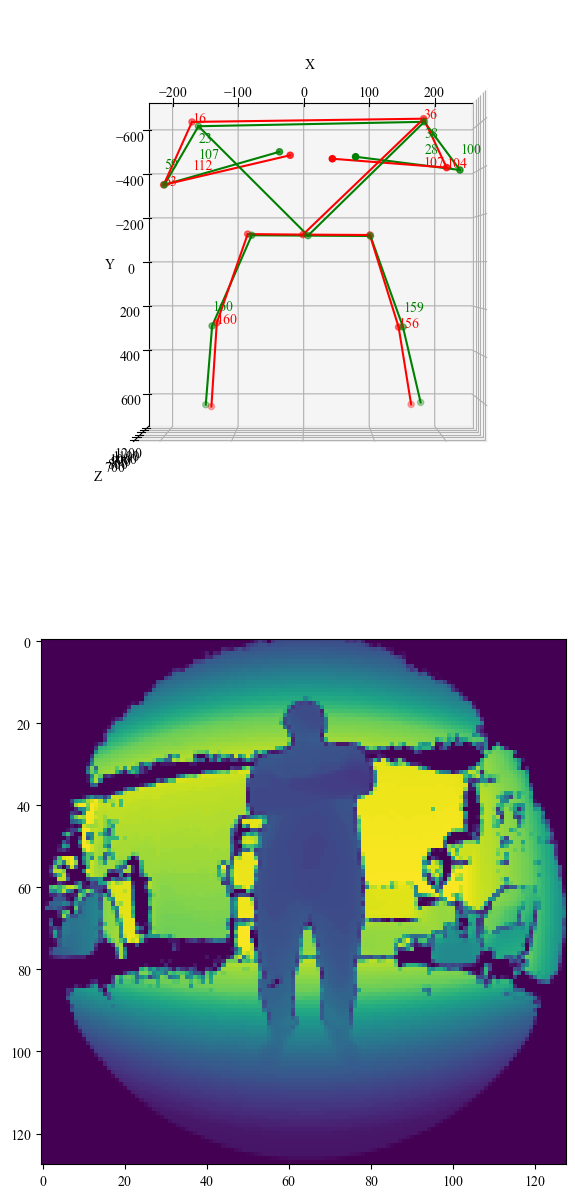

In [9]:
number_of_channels = 7
file_name_full_path_without_extension = File_path
model_name_full_path_without_extension = File_path_karas

play_model(file_name_full_path_without_extension,number_of_channels)

# 4_Analysis

In [10]:
import numpy as np
df_original = pd.read_csv(skeleton_name_full_path+"_tomodel_angles.csv")

df_joints_predicted = df_original[['pelvis_px predicted','pelvis_py predicted','pelvis_pz predicted',"left shoulder_px predicted","left elbow_px predicted","left wrist_px predicted","right shoulder_px predicted","right elbow_px predicted","right wrist_px predicted","left hip_px predicted","left knee_px predicted" ,"left ankle_px predicted","right hip_px predicted","right knee_px predicted","right ankle_px predicted","pelvis_py predicted","left shoulder_py predicted","left elbow_py predicted","left wrist_py predicted","right shoulder_py predicted","right elbow_py predicted","right wrist_py predicted","left hip_py predicted","left knee_py predicted","left ankle_py predicted","right hip_py predicted","right knee_py predicted","right ankle_py predicted","pelvis_pz predicted","left shoulder_pz predicted","left elbow_pz predicted","left wrist_pz predicted","right shoulder_pz predicted","right elbow_pz predicted","right wrist_pz predicted","left hip_pz predicted","left knee_pz predicted","left ankle_pz predicted","right hip_pz predicted","right knee_pz predicted","right ankle_pz predicted"]]
df_joints_predicted_np = df_joints_predicted.to_numpy()
df_joints_kinect = df_original[['pelvis_px','pelvis_py','pelvis_pz',"left shoulder_px","left elbow_px","left wrist_px","right shoulder_px","right elbow_px","right wrist_px","left hip_px","left knee_px" ,"left ankle_px","right hip_px","right knee_px","right ankle_px","pelvis_py","left shoulder_py","left elbow_py","left wrist_py","right shoulder_py","right elbow_py","right wrist_py","left hip_py","left knee_py","left ankle_py","right hip_py","right knee_py","right ankle_py","pelvis_pz","left shoulder_pz","left elbow_pz","left wrist_pz","right shoulder_pz","right elbow_pz","right wrist_pz","left hip_pz","left knee_pz","left ankle_pz","right hip_pz","right knee_pz","right ankle_pz"]]
df_joints_kinect_np = df_joints_kinect.to_numpy()
mean_joint_error_cm = np.mean(np.absolute(df_joints_kinect_np/100 - df_joints_predicted_np/100))
print("\n mean_joint_absolute_error_cm \n",mean_joint_error_cm)
mean_joint_squared_error_cm = np.mean(np.square(df_joints_kinect_np/100 - df_joints_predicted_np/100))
print("\n mean_joint_squared_error_cm \n",mean_joint_squared_error_cm)

df_joints_predicted = df_original[['right_elbow_angle predicted','left_elbow_angle predicted','right_knee_angle predicted','left_knee_angle predicted','right_shoulder_up_angle predicted','left_shoulder_up_angle predicted','right_shoulder_front_angle predicted','left_shoulder_front_angle predicted']]
df_joints_predicted_np = df_joints_predicted.to_numpy()
df_joints_kinect = df_original[['right_elbow_angle kinect','left_elbow_angle kinect','right_knee_angle kinect','left_knee_angle kinect','right_shoulder_up_angle kinect','left_shoulder_up_angle kinect','right_shoulder_front_angle kinect','left_shoulder_front_angle kinect']]
df_joints_kinect_np = df_joints_kinect.to_numpy()
mean_joint_error_cm = np.mean(np.absolute(df_joints_kinect_np - df_joints_predicted_np))
print("\n mean_angles_absolute_error_cm \n",mean_joint_error_cm)
mean_joint_squared_error_cm = np.mean(np.square(df_joints_kinect_np - df_joints_predicted_np))
print("\n mean_angles_squared_error_cm \n",mean_joint_squared_error_cm)



 mean_joint_absolute_error_cm 
 0.5530645650750315

 mean_joint_squared_error_cm 
 7.510783292614004

 mean_angles_absolute_error_cm 
 11.220017337258751

 mean_angles_squared_error_cm 
 655.2756539394832


In [11]:
import numpy as np

# Your existing code for joint positions
df_joints_predicted = df_original[['pelvis_px predicted','pelvis_py predicted','pelvis_pz predicted',"left shoulder_px predicted","left elbow_px predicted","left wrist_px predicted","right shoulder_px predicted","right elbow_px predicted","right wrist_px predicted","left hip_px predicted","left knee_px predicted" ,"left ankle_px predicted","right hip_px predicted","right knee_px predicted","right ankle_px predicted","pelvis_py predicted","left shoulder_py predicted","left elbow_py predicted","left wrist_py predicted","right shoulder_py predicted","right elbow_py predicted","right wrist_py predicted","left hip_py predicted","left knee_py predicted","left ankle_py predicted","right hip_py predicted","right knee_py predicted","right ankle_py predicted","pelvis_pz predicted","left shoulder_pz predicted","left elbow_pz predicted","left wrist_pz predicted","right shoulder_pz predicted","right elbow_pz predicted","right wrist_pz predicted","left hip_pz predicted","left knee_pz predicted","left ankle_pz predicted","right hip_pz predicted","right knee_pz predicted","right ankle_pz predicted"]]
df_joints_predicted_np = df_joints_predicted.to_numpy()
df_joints_kinect = df_original[['pelvis_px','pelvis_py','pelvis_pz',"left shoulder_px","left elbow_px","left wrist_px","right shoulder_px","right elbow_px","right wrist_px","left hip_px","left knee_px" ,"left ankle_px","right hip_px","right knee_px","right ankle_px","pelvis_py","left shoulder_py","left elbow_py","left wrist_py","right shoulder_py","right elbow_py","right wrist_py","left hip_py","left knee_py","left ankle_py","right hip_py","right knee_py","right ankle_py","pelvis_pz","left shoulder_pz","left elbow_pz","left wrist_pz","right shoulder_pz","right elbow_pz","right wrist_pz","left hip_pz","left knee_pz","left ankle_pz","right hip_pz","right knee_pz","right ankle_pz"]]
df_joints_kinect_np = df_joints_kinect.to_numpy()

# Calculate MPJPE for joint positions
M, D = df_joints_predicted_np.shape
MPJPE = 0

for j in range(D):
    joint_error = np.sqrt(np.sum((df_joints_predicted_np[:, j] - df_joints_kinect_np[:, j])**2))
    MPJPE += joint_error

MPJPE /= D  # Divide by the number of dimensions (D)

print("\n Mean Per Joint Position Error (MPJPE) \n", MPJPE)

# Your existing code for joint angles
df_joints_predicted = df_original[['right_elbow_angle predicted','left_elbow_angle predicted','right_knee_angle predicted','left_knee_angle predicted','right_shoulder_up_angle predicted','left_shoulder_up_angle predicted','right_shoulder_front_angle predicted','left_shoulder_front_angle predicted']]
df_joints_predicted_np = df_joints_predicted.to_numpy()
df_joints_kinect = df_original[['right_elbow_angle kinect','left_elbow_angle kinect','right_knee_angle kinect','left_knee_angle kinect','right_shoulder_up_angle kinect','left_shoulder_up_angle kinect','right_shoulder_front_angle kinect','left_shoulder_front_angle kinect']]
df_joints_kinect_np = df_joints_kinect.to_numpy()

# Calculate MAE and MSE for joint angles (you can keep your existing code for this part)
mean_joint_error_cm = np.mean(np.absolute(df_joints_kinect_np - df_joints_predicted_np))
print("\n Mean Angles Absolute Error (in degrees) \n", mean_joint_error_cm)

mean_joint_squared_error_cm = np.mean(np.square(df_joints_kinect_np - df_joints_predicted_np))
print("\n Mean Angles Squared Error (in degrees) \n", mean_joint_squared_error_cm)



 Mean Per Joint Position Error (MPJPE) 
 5024.37144163264

 Mean Angles Absolute Error (in degrees) 
 11.220017337258751

 Mean Angles Squared Error (in degrees) 
 655.2756539394832


In [12]:
import numpy as np

# Your existing code for joint positions
df_joints_predicted = df_original[['pelvis_px predicted','pelvis_py predicted','pelvis_pz predicted',"left shoulder_px predicted","left elbow_px predicted","left wrist_px predicted","right shoulder_px predicted","right elbow_px predicted","right wrist_px predicted","left hip_px predicted","left knee_px predicted" ,"left ankle_px predicted","right hip_px predicted","right knee_px predicted","right ankle_px predicted","pelvis_py predicted","left shoulder_py predicted","left elbow_py predicted","left wrist_py predicted","right shoulder_py predicted","right elbow_py predicted","right wrist_py predicted","left hip_py predicted","left knee_py predicted","left ankle_py predicted","right hip_py predicted","right knee_py predicted","right ankle_py predicted","pelvis_pz predicted","left shoulder_pz predicted","left elbow_pz predicted","left wrist_pz predicted","right shoulder_pz predicted","right elbow_pz predicted","right wrist_pz predicted","left hip_pz predicted","left knee_pz predicted","left ankle_pz predicted","right hip_pz predicted","right knee_pz predicted","right ankle_pz predicted"]]
df_joints_predicted_np = df_joints_predicted.to_numpy()
df_joints_kinect = df_original[['pelvis_px','pelvis_py','pelvis_pz',"left shoulder_px","left elbow_px","left wrist_px","right shoulder_px","right elbow_px","right wrist_px","left hip_px","left knee_px" ,"left ankle_px","right hip_px","right knee_px","right ankle_px","pelvis_py","left shoulder_py","left elbow_py","left wrist_py","right shoulder_py","right elbow_py","right wrist_py","left hip_py","left knee_py","left ankle_py","right hip_py","right knee_py","right ankle_py","pelvis_pz","left shoulder_pz","left elbow_pz","left wrist_pz","right shoulder_pz","right elbow_pz","right wrist_pz","left hip_pz","left knee_pz","left ankle_pz","right hip_pz","right knee_pz","right ankle_pz"]]
df_joints_kinect_np = df_joints_kinect.to_numpy()

# Calculate the MAE and MSE for joint positions (already in cm)
mean_joint_error_cm = np.mean(np.absolute(df_joints_kinect_np - df_joints_predicted_np))
print("\n Mean Joint Absolute Error (in cm) \n", mean_joint_error_cm)

mean_joint_squared_error_cm = np.mean(np.square(df_joints_kinect_np - df_joints_predicted_np))
print("\n Mean Joint Squared Error (in cm^2) \n", mean_joint_squared_error_cm)

# Your existing code for joint angles (in degrees)
df_joints_predicted = df_original[['right_elbow_angle predicted','left_elbow_angle predicted','right_knee_angle predicted','left_knee_angle predicted','right_shoulder_up_angle predicted','left_shoulder_up_angle predicted','right_shoulder_front_angle predicted','left_shoulder_front_angle predicted']]
df_joints_predicted_np = df_joints_predicted.to_numpy()
df_joints_kinect = df_original[['right_elbow_angle kinect','left_elbow_angle kinect','right_knee_angle kinect','left_knee_angle kinect','right_shoulder_up_angle kinect','left_shoulder_up_angle kinect','right_shoulder_front_angle kinect','left_shoulder_front_angle kinect']]
df_joints_kinect_np = df_joints_kinect.to_numpy()

# Calculate MAE and MSE for joint angles (in degrees)
mean_joint_error_deg = np.mean(np.absolute(df_joints_kinect_np - df_joints_predicted_np))
print("\n Mean Angles Absolute Error (in degrees) \n", mean_joint_error_deg)

mean_joint_squared_error_deg = np.mean(np.square(df_joints_kinect_np - df_joints_predicted_np))
print("\n Mean Angles Squared Error (in degrees) \n", mean_joint_squared_error_deg)



 Mean Joint Absolute Error (in cm) 
 55.30645650750315

 Mean Joint Squared Error (in cm^2) 
 75107.83292614002

 Mean Angles Absolute Error (in degrees) 
 11.220017337258751

 Mean Angles Squared Error (in degrees) 
 655.2756539394832


In [13]:
import numpy as np

# Define joint names for positions
joint_names = [
    'pelvis', 'left_shoulder', 'left_elbow', 'left_wrist', 'right_shoulder', 'right_elbow', 'right_wrist',
    'left_hip', 'left_knee', 'left_ankle', 'right_hip', 'right_knee', 'right_ankle'
]

# Your existing code for joint positions
df_joints_predicted = df_original[['pelvis_px predicted','pelvis_py predicted','pelvis_pz predicted',"left shoulder_px predicted","left elbow_px predicted","left wrist_px predicted","right shoulder_px predicted","right elbow_px predicted","right wrist_px predicted","left hip_px predicted","left knee_px predicted" ,"left ankle_px predicted","right hip_px predicted","right knee_px predicted","right ankle_px predicted","pelvis_py predicted","left shoulder_py predicted","left elbow_py predicted","left wrist_py predicted","right shoulder_py predicted","right elbow_py predicted","right wrist_py predicted","left hip_py predicted","left knee_py predicted","left ankle_py predicted","right hip_py predicted","right knee_py predicted","right ankle_py predicted","pelvis_pz predicted","left shoulder_pz predicted","left elbow_pz predicted","left wrist_pz predicted","right shoulder_pz predicted","right elbow_pz predicted","right wrist_pz predicted","left hip_pz predicted","left knee_pz predicted","left ankle_pz predicted","right hip_pz predicted","right knee_pz predicted","right ankle_pz predicted"]]
df_joints_predicted_np = df_joints_predicted.to_numpy()
df_joints_kinect = df_original[['pelvis_px','pelvis_py','pelvis_pz',"left shoulder_px","left elbow_px","left wrist_px","right shoulder_px","right elbow_px","right wrist_px","left hip_px","left knee_px" ,"left ankle_px","right hip_px","right knee_px","right ankle_px","pelvis_py","left shoulder_py","left elbow_py","left wrist_py","right shoulder_py","right elbow_py","right wrist_py","left hip_py","left knee_py","left ankle_py","right hip_py","right knee_py","right ankle_py","pelvis_pz","left shoulder_pz","left elbow_pz","left wrist_pz","right shoulder_pz","right elbow_pz","right wrist_pz","left hip_pz","left knee_pz","left ankle_pz","right hip_pz","right knee_pz","right ankle_pz"]]
df_joints_kinect_np = df_joints_kinect.to_numpy()

# Calculate the Euclidean distance (in cm) for joint positions
euclidean_distances = np.sqrt(np.sum((df_joints_predicted_np/100 - df_joints_kinect_np/100)**2, axis=0))

# Print the Euclidean distances with joint names
for joint_name, distance in zip(joint_names, euclidean_distances):
    print(f"Euclidean Distance for {joint_name}: {distance} cm")

# Your existing code for joint angles (in degrees)
df_joints_predicted = df_original[['right_elbow_angle predicted','left_elbow_angle predicted','right_knee_angle predicted','left_knee_angle predicted','right_shoulder_up_angle predicted','left_shoulder_up_angle predicted','right_shoulder_front_angle predicted','left_shoulder_front_angle predicted']]
df_joints_predicted_np = df_joints_predicted.to_numpy()
df_joints_kinect = df_original[['right_elbow_angle kinect','left_elbow_angle kinect','right_knee_angle kinect','left_knee_angle kinect','right_shoulder_up_angle kinect','left_shoulder_up_angle kinect','right_shoulder_front_angle kinect','left_shoulder_front_angle kinect']]
df_joints_kinect_np = df_joints_kinect.to_numpy()

# Calculate MAE and MSE for joint angles (you can keep your existing code for this part)
mean_joint_error_deg = np.mean(np.absolute(df_joints_kinect_np - df_joints_predicted_np))
print("\n Mean Angles Absolute Error (in degrees) \n", mean_joint_error_deg)

mean_joint_squared_error_deg = np.mean(np.square(df_joints_kinect_np - df_joints_predicted_np))
print("\n Mean Angles Squared Error (in degrees) \n", mean_joint_squared_error_deg)

# Calculate the Euclidean distance (in cm) for joint positions
euclidean_distances = np.sqrt(np.sum((df_joints_predicted_np/100 - df_joints_kinect_np/100)**2, axis=0))

# Calculate the mean of the distances for joint positions
mean_distance = np.mean(euclidean_distances)
print("\n")
# Print the mean distance
print("Mean Euclidean Distance for Joint Positions: {:.2f} cm".format(mean_distance))



Euclidean Distance for pelvis: 8.085179958919014 cm
Euclidean Distance for left_shoulder: 4.9103490439022845 cm
Euclidean Distance for left_elbow: 17.989601381958263 cm
Euclidean Distance for left_wrist: 10.361144657438606 cm
Euclidean Distance for right_shoulder: 14.2822949578703 cm
Euclidean Distance for right_elbow: 17.80116456538912 cm
Euclidean Distance for right_wrist: 10.668811990220794 cm
Euclidean Distance for left_hip: 11.753237679435713 cm
Euclidean Distance for left_knee: 18.07730454124936 cm
Euclidean Distance for left_ankle: 7.239585011508889 cm
Euclidean Distance for right_hip: 8.47040455020728 cm
Euclidean Distance for right_knee: 8.555241371853674 cm
Euclidean Distance for right_ankle: 7.835825978866558 cm

 Mean Angles Absolute Error (in degrees) 
 11.220017337258751

 Mean Angles Squared Error (in degrees) 
 655.2756539394832


Mean Euclidean Distance for Joint Positions: 10.93 cm


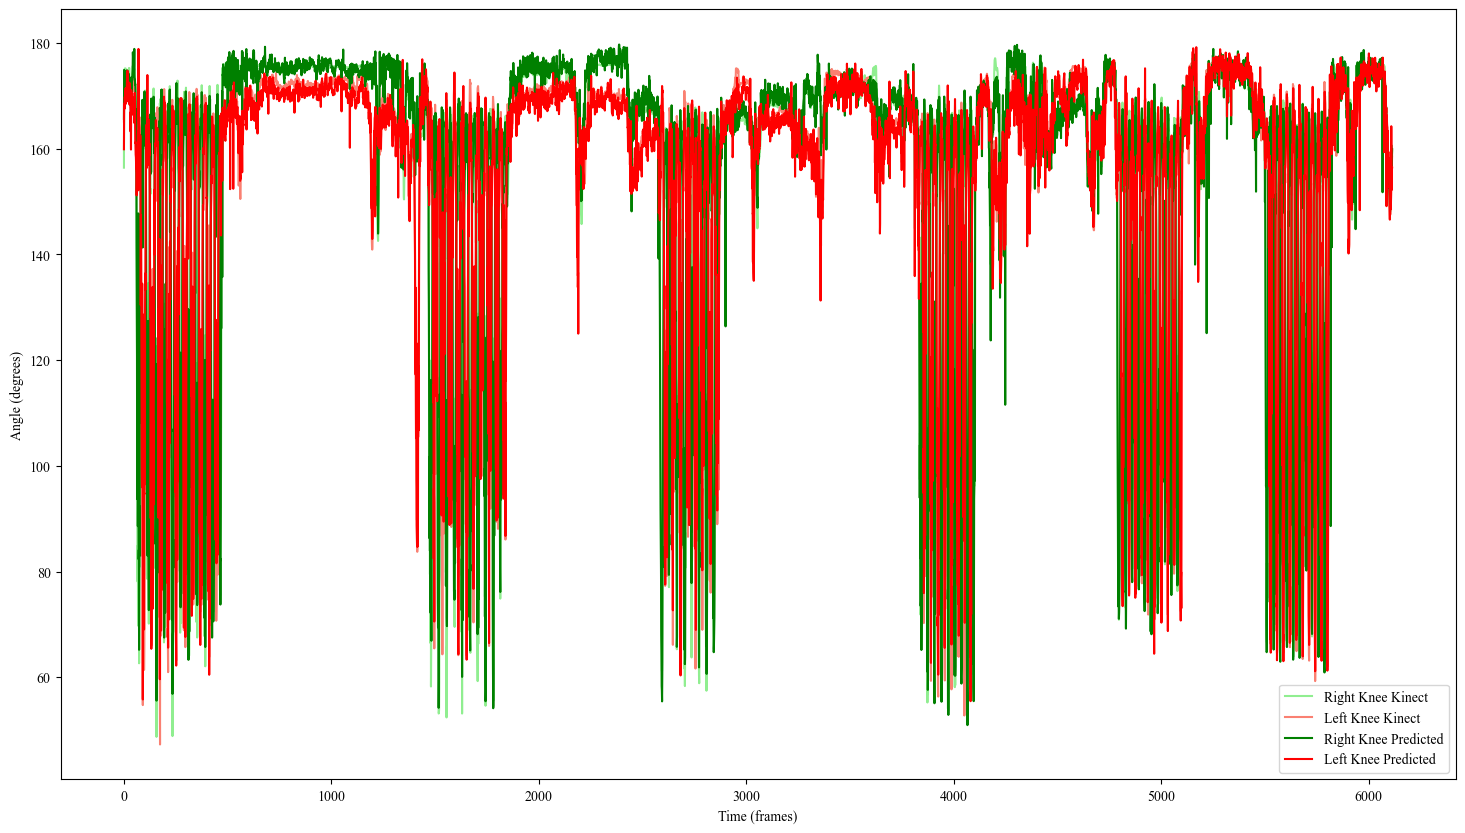

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df_original = pd.read_csv(skeleton_name_full_path+"_tomodel_angles.csv")


# Your data plots
df_original["right_knee_angle kinect"].plot(kind="line", color="lightgreen", figsize=(18, 10), label="Right Knee Kinect")
df_original["left_knee_angle kinect"].plot(kind="line", color="salmon", label="Left Knee Kinect")
df_original["right_knee_angle predicted"].plot(kind="line", color="g", label="Right Knee Predicted")
df_original["left_knee_angle predicted"].plot(kind="line", color="r", label="Left Knee Predicted")

# Add X and Y axes labels
plt.xlabel("Time (frames)")  # Replace "Time" with the appropriate label for your X-axis
plt.ylabel("Angle (degrees)")  # Replace "Angle" with the appropriate label for your Y-axis

# Add a legend
plt.legend()

# Show the plot
plt.show()




Recond period: 141.96680272108844  seconds
kinect f/s :  43.06640625
right knees up count 64
right knees up wrong count 5
left knees up count 65
left knees up wrong count 13
exersize total time :  296.0
average single motion time (rise and fall of both knees) :  4.589147286821706


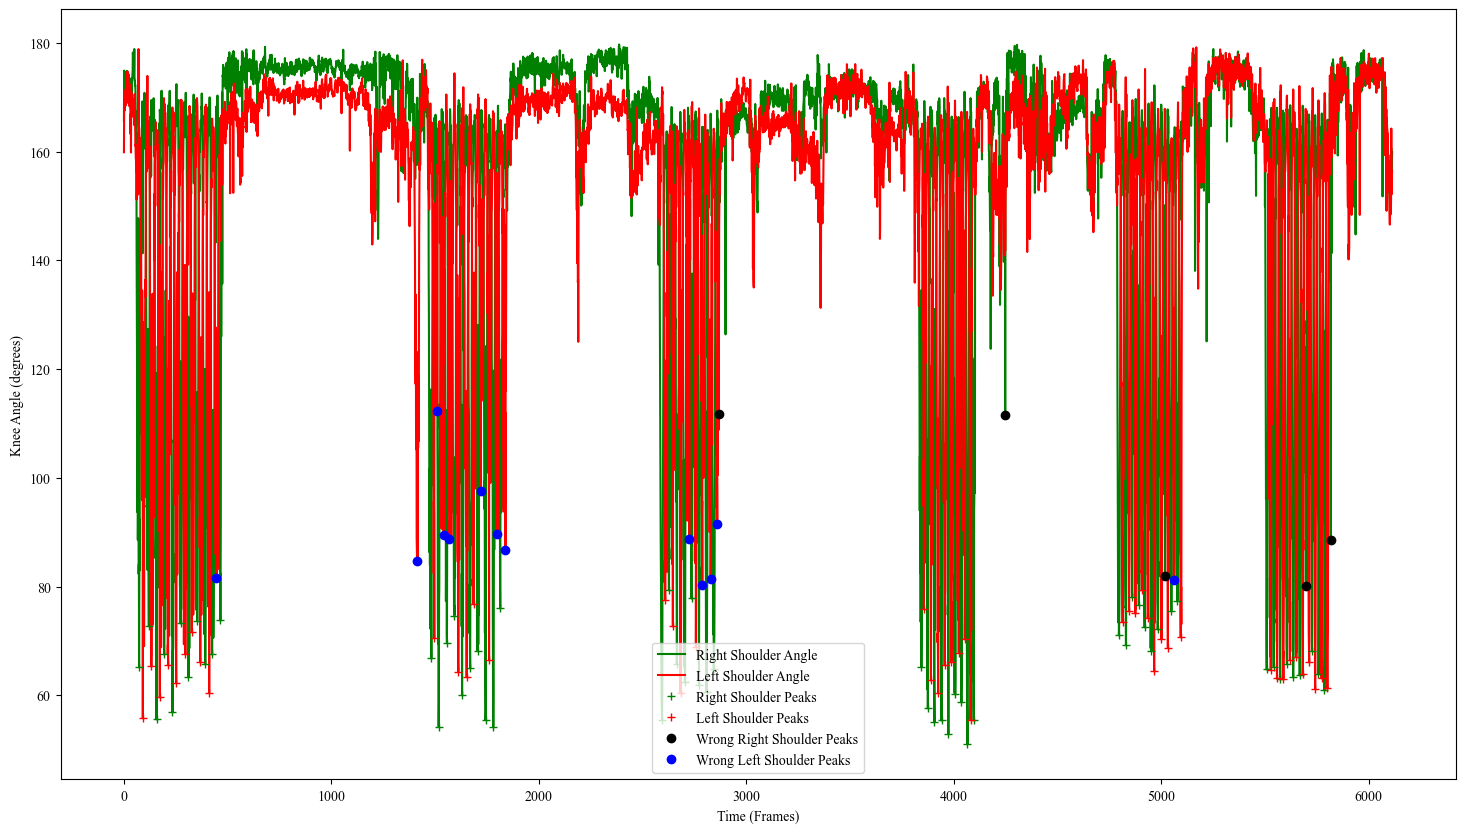

In [15]:

# this code counts buttoms , for knee

from scipy.signal import argrelextrema
import time,datetime
from matplotlib import pyplot as plt
import numpy as np

df_original = pd.read_csv(skeleton_name_full_path+"_tomodel_angles.csv")

ch1_ndarray = recording.T[0]
record_period = len(ch1_ndarray) / sf
kinect_fps = len(df_original)/record_period
print("Recond period:" , len(ch1_ndarray) / sf ," seconds")
print("kinect f/s : " , kinect_fps)
kinect_excel_df = pd.read_csv(file_name_full_path_without_extension + ".csv")
time_stamp = kinect_excel_df["time"]

# analyzing motion
right_knee_angle_predicted = df_original["right_knee_angle predicted"]
left_knee_angle_predicted = df_original["left_knee_angle predicted"]

right_knee_angle_predicted_np = right_knee_angle_predicted.to_numpy()
left_knee_angle_predicted_np = left_knee_angle_predicted.to_numpy()
time_stamp_np = time_stamp.to_numpy() 

minimums_right_knee_angle_predicted = np.asarray(argrelextrema(right_knee_angle_predicted_np, np.less,order = 10))[0]
minimums_right_knee_angle_predicted = [x for x in minimums_right_knee_angle_predicted if right_knee_angle_predicted_np[x] <= 120]
minimums_right_knee_angle_predicted_bad = [x for x in minimums_right_knee_angle_predicted if right_knee_angle_predicted_np[x] <= 120 and right_knee_angle_predicted_np[x] > 80]

minimums_left_knee_angle_predicted = np.asarray(argrelextrema(left_knee_angle_predicted_np, np.less,order = 10))[0]
minimums_left_knee_angle_predicted = [x for x in minimums_left_knee_angle_predicted if left_knee_angle_predicted_np[x] <= 120]
minimums_left_knee_angle_predicted_bad = [x for x in minimums_left_knee_angle_predicted if left_knee_angle_predicted_np[x] <= 120 and left_knee_angle_predicted_np[x] > 80]


# knee exercise
right_knees_up_count_predicted=0
left_knees_up_count_predicted=0
right_knee_status_predicted = "down"
left_knee_status_predicted = "down"

fuzzy_knee_up_predicted = 100
fuzzy_knee_down_predicted = 150

first_left_knee_rise_time_predicted_at = 0
first_right_knee_rise_time_predicted_at = 0
last_left_knee_rise_time_predicted_at = 0
last_right_knee_rise_time_predicted_at = 0
first_knee_rise_time_predicted_at = 0
last_knee_rise_time_predicted_at = 0

for index in range(0,len(right_knee_angle_predicted_np)):
  if right_knee_status_predicted == "down" and right_knee_angle_predicted_np[index] < fuzzy_knee_up_predicted and left_knee_angle_predicted_np[index] > fuzzy_knee_down_predicted:
    right_knee_status_predicted = "up"
    right_knees_up_count_predicted += 1
    if right_knees_up_count_predicted == 1: first_right_knee_rise_time_predicted_at = time_stamp_np[index]
    last_right_knee_rise_time_predicted_at = time_stamp_np[index]
    if first_knee_rise_time_predicted_at == 0 :
      first_knee_rise_time_predicted_at = time_stamp_np[index]
    last_knee_rise_time_predicted_at = time_stamp_np[index]
  if right_knee_status_predicted == "up" and right_knee_angle_predicted_np[index] > fuzzy_knee_down_predicted:
    right_knee_status_predicted = "down"

  if left_knee_status_predicted == "down" and left_knee_angle_predicted_np[index] < fuzzy_knee_up_predicted and right_knee_angle_predicted_np[index] > fuzzy_knee_down_predicted:
    left_knee_status_predicted = "up"
    left_knees_up_count_predicted += 1
    if left_knees_up_count_predicted == 1: first_left_knee_rise_time_predicted_at = time_stamp_np[index]
    last_left_knee_rise_time_predicted_at = time_stamp_np[index]
    if first_knee_rise_time_predicted_at == 0 :
      first_knee_rise_time_predicted_at = time_stamp_np[index]
    last_knee_rise_time_predicted_at = time_stamp_np[index]
  if left_knee_status_predicted == "up" and left_knee_angle_predicted_np[index] > fuzzy_knee_down_predicted:
    left_knee_status_predicted = "down"

print("right knees up count",right_knees_up_count_predicted)
print("right knees up wrong count",len(minimums_right_knee_angle_predicted_bad))
print("left knees up count",left_knees_up_count_predicted)
print("left knees up wrong count",len(minimums_left_knee_angle_predicted_bad))
print("exersize total time : ", (time.mktime(datetime.datetime.strptime(last_knee_rise_time_predicted_at,"%Y-%m-%dT%H:%M:%S.%f").timetuple()) - time.mktime(datetime.datetime.strptime(first_knee_rise_time_predicted_at,"%Y-%m-%dT%H:%M:%S.%f").timetuple())))
if right_knees_up_count_predicted+left_knees_up_count_predicted != 0 :
  print("average single motion time (rise and fall of both knees) : ", (2*(time.mktime(datetime.datetime.strptime(last_knee_rise_time_predicted_at,"%Y-%m-%dT%H:%M:%S.%f").timetuple()) - time.mktime(datetime.datetime.strptime(first_knee_rise_time_predicted_at,"%Y-%m-%dT%H:%M:%S.%f").timetuple()))/(right_knees_up_count_predicted+left_knees_up_count_predicted)))
else:
  print("no knee rises")



df_original["right_knee_angle predicted"].plot(kind="line",color="g", figsize=(18, 10), label="Right Shoulder Angle")
df_original["left_knee_angle predicted"].plot(kind="line",color="r", figsize=(18, 10), label="Left Shoulder Angle")
plt.plot(minimums_right_knee_angle_predicted,  right_knee_angle_predicted_np[minimums_right_knee_angle_predicted],'g+', label="Right Shoulder Peaks")
plt.plot(minimums_left_knee_angle_predicted,  left_knee_angle_predicted_np[minimums_left_knee_angle_predicted],'r+', label="Left Shoulder Peaks")
plt.plot(minimums_right_knee_angle_predicted_bad,  right_knee_angle_predicted_np[minimums_right_knee_angle_predicted_bad],'ko', label="Wrong Right Shoulder Peaks")
plt.plot(minimums_left_knee_angle_predicted_bad,  left_knee_angle_predicted_np[minimums_left_knee_angle_predicted_bad],'bo', label="Wrong Left Shoulder Peaks")

# Add x and y axis labels
plt.xlabel("Time (Frames)")
plt.ylabel("Knee Angle (degrees)")

# Add a legend to the plot
plt.legend()

plt.show()



In [16]:
import functions

# values to change
angle_1=120
angle_2=130
angle_1_wrong=90
direction="down"
show_plots=False

right_angle_col_name = "right_knee_angle predicted"
left_angle_col_name = "left_knee_angle predicted"
right_total_count_predicted,right_wrong_count_predicted,left_total_count_predicted,left_wrong_count_predicted,exersize_total_time_predicted,average_single_motion_time_predicted,phase_difference_predicted,mean_difference_predicted,right_std_predicted,left_std_predicted = functions.analyse_joints(skeleton_name_full_path,right_angle_col_name,left_angle_col_name,angle_1,angle_2,angle_1_wrong,direction,show_plots)
print("predicted")
print(right_angle_col_name + " count",right_total_count_predicted)
print(right_angle_col_name + " wrong count",right_wrong_count_predicted)
print(left_angle_col_name + " count",left_total_count_predicted)
print(left_angle_col_name + " wrong count",left_wrong_count_predicted)
print("exersize total time : ", exersize_total_time_predicted)
print("average single motion time (rise and fall) : ", average_single_motion_time_predicted)
print("out of phase : ",phase_difference_predicted)
print("Mean shift",mean_difference_predicted)
print("right peaks std",right_std_predicted)
print("left peaks std",left_std_predicted)

right_angle_col_name = "right_knee_angle kinect"
left_angle_col_name = "left_knee_angle kinect"
right_total_count_kinect,right_wrong_count_kinect,left_total_count_kinect,left_wrong_count_kinect,exersize_total_time_kinect,average_single_motion_time_kinect,phase_difference_kinect,mean_difference_kinect,right_std_kinect,left_std_kinect = functions.analyse_joints(skeleton_name_full_path,right_angle_col_name,left_angle_col_name,angle_1,angle_2,angle_1_wrong,direction,show_plots)
print("\nkinect")
print(right_angle_col_name + " count",right_total_count_kinect)
print(right_angle_col_name + " wrong count",right_wrong_count_kinect)
print(left_angle_col_name + " count",left_total_count_kinect)
print(left_angle_col_name + " wrong count",left_wrong_count_kinect)
print("exersize total time : ", exersize_total_time_kinect)
print("average single motion time (rise and fall) : ", average_single_motion_time_kinect)
print("out of phase : ",phase_difference_kinect)
print("Mean shift",mean_difference_kinect)
print("right peaks std",right_std_kinect)
print("left peaks std",left_std_kinect)
print("\n")
print("Miscount in right count:",abs(right_total_count_kinect-right_total_count_predicted)/(right_total_count_kinect+right_total_count_predicted)*100," %")
print("Miscount in left count:",abs(left_total_count_kinect-left_total_count_predicted)/(left_total_count_kinect+left_total_count_predicted)*100," %")



predicted
right_knee_angle predicted count 88
right_knee_angle predicted wrong count 2
left_knee_angle predicted count 104
left_knee_angle predicted wrong count 3
exersize total time :  296.0
average single motion time (rise and fall) :  3.0833333333333335
out of phase :  5664.7725
Mean shift -4.080704070096104
right peaks std 11.476355264988722
left peaks std 6.029652703632078

kinect
right_knee_angle kinect count 65
right_knee_angle kinect wrong count 0
left_knee_angle kinect count 80
left_knee_angle kinect wrong count 2
exersize total time :  295.0
average single motion time (rise and fall) :  4.068965517241379
out of phase :  5735.522
Mean shift -4.40460344827585
right peaks std 8.460680254202527
left peaks std 3.1857082171050015


Miscount in right count: 15.032679738562091  %
Miscount in left count: 13.043478260869565  %
